# Credit Risk: PD (Logit) + LGD (Three Tobit Variants) + EL Portfolio Analysis
### Full Framework: Logit PD × [Tobit I | Two-Limit Tobit | Heckman Tobit] × EAD

**Dataset:** UCI Default of Credit Card Clients (Taiwan, 2005)

---
### Model Pipeline
1. Setup & Data Loading  
2. Feature Engineering & LGD Proxy Construction (with boundary counts)  
3. **PD Model** — Logistic Regression with full diagnostics  
4. **LGD Model 1** — Simple Tobit (Left-Censored at 0) + Full Diagnostics  
5. **LGD Model 2** — Two-Limit Tobit (Censored at 0 AND 1) + Full Diagnostics  
6. **LGD Model 3** — Heckman's Tobit (Selection Model) + Full Diagnostics  
7. **Model Comparison** — RMSE, MAE, R², AIC, BIC, Log-Likelihood  
8. **EL Computation** — PD × LGD × EAD for each model  
9. **Portfolio Analysis** — Average EL/EAD, Concentration, Gini, HHI  

## 1. Setup & Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.base.model import GenericLikelihoodModel
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.stats import norm, chi2, shapiro
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, brier_score_loss,
                              precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold'
})

C = {
    'pd':      '#2563EB',
    'lgd':     '#DC2626',
    'el':      '#16A34A',
    'tobit1':  '#7C3AED',
    'tobit2':  '#EA580C',
    'heckman': '#0891B2',
    'neutral': '#6B7280',
    'light':   '#E5E7EB'
}

print("Libraries loaded.")

Libraries loaded.


## 2. Data Loading & Feature Engineering

In [2]:
df = pd.read_csv('UCI_Credit_Card.csv')
df.drop(columns=['ID'], inplace=True)
df.rename(columns={'default.payment.next.month': 'DEFAULT'}, inplace=True)

# Fix undocumented category codes
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE']  = df['MARRIAGE'].replace(0, 3)

print(f"Dataset shape    : {df.shape}")
print(f"Default rate     : {df['DEFAULT'].mean():.3%}  ({df['DEFAULT'].sum():,} defaults)")
print(f"Non-defaulters   : {(df['DEFAULT']==0).sum():,}")
print(f"Missing values   : {df.isnull().sum().sum()}")

Dataset shape    : (30000, 24)
Default rate     : 22.120%  (6,636 defaults)
Non-defaulters   : 23,364
Missing values   : 0


In [4]:
bill_cols  = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols   = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
repay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df['AVG_BILL']       = df[bill_cols].mean(axis=1)
df['AVG_PAY_AMT']    = df[pay_cols].mean(axis=1)
df['UTIL_RATIO']     = (df['AVG_BILL'] / df['LIMIT_BAL'].replace(0, np.nan)).clip(upper=1).fillna(0)
df['MAX_DELAY']      = df[repay_cols].max(axis=1)
df['N_DELAY']        = (df[repay_cols] > 0).sum(axis=1)

total_bill = df[bill_cols].sum(axis=1).replace(0, np.nan)
df['PAY_BILL_RATIO'] = (df[pay_cols].sum(axis=1) / total_bill).clip(upper=5).fillna(0)

# ─── Construct proxy LGD ──────────────────────────────────────────────────────
# LGD = 1 − Recovery Rate;  Recovery = total_payments / most_recent_bill
total_paid     = df[pay_cols].sum(axis=1)
total_exposure = df['BILL_AMT1'].replace(0, np.nan)
recovery_rate  = (total_paid / total_exposure).clip(lower=0, upper=1).fillna(0)
df['LGD_proxy']  = (1 - recovery_rate).clip(lower=0, upper=1)
df['CENSORED']   = (df['DEFAULT'] == 0).astype(int)   # 1 = not observed (non-defaulter)

# ─── LGD Boundary counts (very important for Two-Limit Tobit justification) ───
defaulters = df[df['DEFAULT'] == 1].copy()

n_lgd_zero  = (defaulters['LGD_proxy'] == 0.0).sum()
n_lgd_one   = (defaulters['LGD_proxy'] == 1.0).sum()
n_lgd_mid   = ((defaulters['LGD_proxy'] > 0) & (defaulters['LGD_proxy'] < 1)).sum()
n_lgd_total = len(defaulters)

print("=" * 60)
print("LGD PROXY — OBSERVATION COUNTS (DEFAULTERS ONLY)")
print("=" * 60)
print(f"  Total defaulters (uncensored LGD obs): {n_lgd_total:>7,}")
print(f"  LGD = 0  (full recovery — lower bound): {n_lgd_zero:>7,}  ({n_lgd_zero/n_lgd_total:.2%})")
print(f"  LGD = 1  (zero recovery — upper bound): {n_lgd_one:>7,}  ({n_lgd_one/n_lgd_total:.2%})")
print(f"  LGD in (0,1) strictly interior        : {n_lgd_mid:>7,}  ({n_lgd_mid/n_lgd_total:.2%})")
print()
print("─" * 60)
print("FULL DATASET — CENSORING STRUCTURE")
print("─" * 60)
print(f"  Non-defaulters (CENSORED at 0)         : {df['CENSORED'].sum():>7,}")
print(f"  Defaulters (UNCENSORED)                : {(1-df['CENSORED']).sum():>7,}")
print(f"  Total observations                     : {len(df):>7,}")
print()
print("NOTE:")
print(f"  → Both boundary spikes exist, justifying the TWO-LIMIT Tobit.")
print(f"  → {n_lgd_zero} obs at LGD=0 → left-censored within defaulters.")
print(f"  → {n_lgd_one} obs at LGD=1 → right-censored within defaulters.")

LGD PROXY — OBSERVATION COUNTS (DEFAULTERS ONLY)
  Total defaulters (uncensored LGD obs):   6,636
  LGD = 0  (full recovery — lower bound):   1,480  (22.30%)
  LGD = 1  (zero recovery — upper bound):     870  (13.11%)
  LGD in (0,1) strictly interior        :   4,286  (64.59%)

────────────────────────────────────────────────────────────
FULL DATASET — CENSORING STRUCTURE
────────────────────────────────────────────────────────────
  Non-defaulters (CENSORED at 0)         :  23,364
  Defaulters (UNCENSORED)                :   6,636
  Total observations                     :  30,000

NOTE:
  → Both boundary spikes exist, justifying the TWO-LIMIT Tobit.
  → 1480 obs at LGD=0 → left-censored within defaulters.
  → 870 obs at LGD=1 → right-censored within defaulters.


## 3. PD Model — Logistic Regression with Full Diagnostics

In [31]:
pd_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO', 'MAX_DELAY', 'N_DELAY',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]

X_pd_raw = df[pd_features].astype(float)
y_pd     = df['DEFAULT']

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_pd_raw, y_pd, test_size=0.30, random_state=42, stratify=y_pd
)

scaler_pd   = StandardScaler()
X_train_sc  = scaler_pd.fit_transform(X_train)
X_test_sc   = scaler_pd.transform(X_test)
X_full_sc   = scaler_pd.transform(X_pd_raw)

# Fit Logit (sklearn)
lr_pd1 = LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='lbfgs')
lr_pd1.fit(X_full_sc, y_pd)

# Statsmodels Logit for rich output & diagnostics
X_sm_full  = sm.add_constant(X_full_sc)
logit_sm1   = sm.Logit(y_pd, X_sm_full).fit(disp=False, maxiter=500)

print(logit_sm1.summary(xname=['const'] + pd_features))

                           Logit Regression Results                           
Dep. Variable:                DEFAULT   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29991
Method:                           MLE   Df Model:                            8
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1406
Time:                        11:14:24   Log-Likelihood:                -13624.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.4407      0.016    -87.970      0.000      -1.473      -1.409
LIMIT_BAL         -0.1566      0.025     -6.165      0.000      -0.206      -0.107
AGE                0.0813      0.015

In [32]:
pd_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO', 'MAX_DELAY', 'N_DELAY',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]

X_pd_raw = df[pd_features].astype(float)
y_pd     = df['DEFAULT']

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_pd_raw, y_pd, test_size=0.30, random_state=42, stratify=y_pd
)

scaler_pd   = StandardScaler()
X_train_sc  = scaler_pd.fit_transform(X_train)
X_test_sc   = scaler_pd.transform(X_test)
X_full_sc   = scaler_pd.transform(X_pd_raw)

# Fit Logit (sklearn)
lr_pd = LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='lbfgs')
lr_pd.fit(X_train_sc, y_train)

# Statsmodels Logit for rich output & diagnostics
X_sm_train = sm.add_constant(X_train_sc)
X_sm_full  = sm.add_constant(X_full_sc)
logit_sm   = sm.Logit(y_train, X_sm_train).fit(disp=False, maxiter=500)

print(logit_sm.summary(xname=['const'] + pd_features))

                           Logit Regression Results                           
Dep. Variable:                DEFAULT   No. Observations:                21000
Model:                          Logit   Df Residuals:                    20991
Method:                           MLE   Df Model:                            8
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1442
Time:                        11:14:26   Log-Likelihood:                -9496.1
converged:                       True   LL-Null:                       -11097.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.4442      0.020    -73.866      0.000      -1.482      -1.406
LIMIT_BAL         -0.1491      0.030     -4.894      0.000      -0.209      -0.089
AGE                0.0631      0.018

In [33]:
# ─── PD Diagnostics ──────────────────────────────────────────────────────────
y_pred_prob_train = lr_pd.predict_proba(X_train_sc)[:, 1]
y_pred_prob_test  = lr_pd.predict_proba(X_test_sc)[:, 1]
y_pred_class_test = lr_pd.predict(X_test_sc)

auc_train = roc_auc_score(y_train, y_pred_prob_train)
auc_test  = roc_auc_score(y_test,  y_pred_prob_test)
brier     = brier_score_loss(y_test, y_pred_prob_test)
ap_score  = average_precision_score(y_test, y_pred_prob_test)

# Cross-validation AUC
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc    = cross_val_score(lr_pd, X_full_sc, y_pd, cv=cv, scoring='roc_auc')

print("=" * 55)
print("PD MODEL (LOGIT) — PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  AUC  (Train)          : {auc_train:.4f}")
print(f"  AUC  (Test)           : {auc_test:.4f}")
print(f"  AUC  (5-Fold CV mean) : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")
print(f"  Brier Score (Test)    : {brier:.4f}  (lower = better, perfect = 0)")
print(f"  Avg Precision (Test)  : {ap_score:.4f}")
print(f"  McFadden R²           : {logit_sm.prsquared:.4f}")
print(f"  Log-Likelihood        : {logit_sm.llf:.2f}")
print(f"  LLR p-value           : {logit_sm.llr_pvalue:.4e}")
print(f"  AIC                   : {logit_sm.aic:.2f}")
print(f"  BIC                   : {logit_sm.bic:.2f}")
print()
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_class_test, target_names=['No Default','Default']))

PD MODEL (LOGIT) — PERFORMANCE SUMMARY
  AUC  (Train)          : 0.7477
  AUC  (Test)           : 0.7342
  AUC  (5-Fold CV mean) : 0.7437  ± 0.0054
  Brier Score (Test)    : 0.1456  (lower = better, perfect = 0)
  Avg Precision (Test)  : 0.4889
  McFadden R²           : 0.1442
  Log-Likelihood        : -9496.11
  LLR p-value           : 0.0000e+00
  AIC                   : 19010.22
  BIC                   : 19081.79

Classification Report (Test Set):
              precision    recall  f1-score   support

  No Default       0.82      0.96      0.88      7009
     Default       0.62      0.26      0.36      1991

    accuracy                           0.80      9000
   macro avg       0.72      0.61      0.62      9000
weighted avg       0.78      0.80      0.77      9000



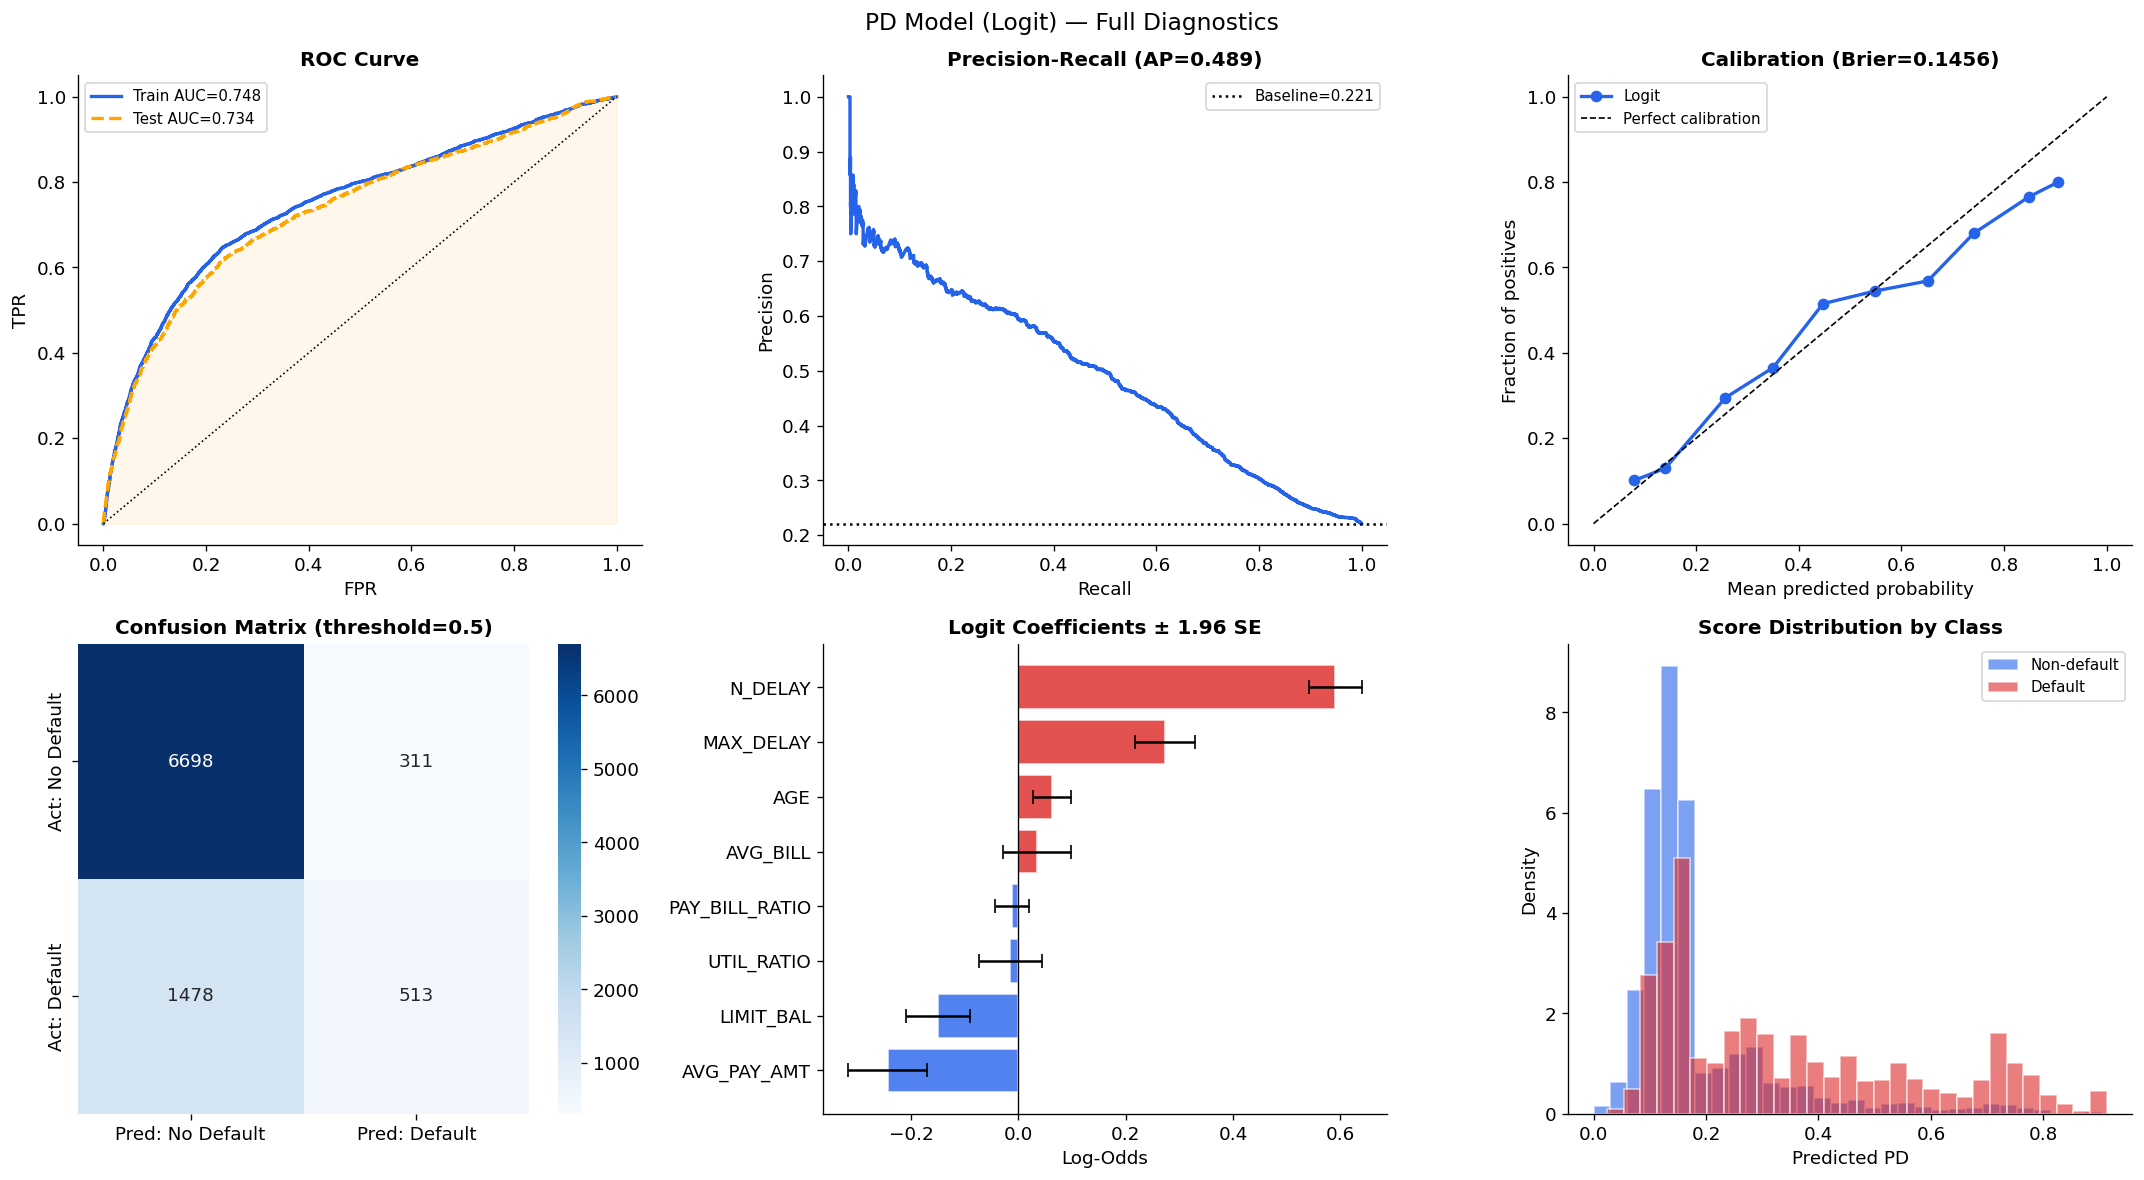


Full-sample PD — Mean: 0.2212 | Actual default rate: 0.2212


In [34]:
# ─── PD Visual Diagnostics ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('PD Model (Logit) — Full Diagnostics', fontsize=14)

# 1. ROC Curve
ax = axes[0, 0]
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_pred_prob_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_pred_prob_test)
ax.plot(fpr_tr, tpr_tr, color=C['pd'], lw=2, label=f'Train AUC={auc_train:.3f}')
ax.plot(fpr_te, tpr_te, color='orange', lw=2, linestyle='--', label=f'Test AUC={auc_test:.3f}')
ax.plot([0,1],[0,1],'k:', lw=1)
ax.fill_between(fpr_te, tpr_te, alpha=0.08, color='orange')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curve')
ax.legend(fontsize=9)

# 2. Precision-Recall Curve
ax = axes[0, 1]
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob_test)
ax.plot(rec, prec, color=C['pd'], lw=2)
ax.axhline(y_test.mean(), color='k', linestyle=':', label=f'Baseline={y_test.mean():.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall (AP={ap_score:.3f})')
ax.legend(fontsize=9)

# 3. Calibration Plot
ax = axes[0, 2]
frac_pos, mean_pred = calibration_curve(y_test, y_pred_prob_test, n_bins=10)
ax.plot(mean_pred, frac_pos, marker='o', color=C['pd'], lw=2, label='Logit')
ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title(f'Calibration (Brier={brier:.4f})')
ax.legend(fontsize=9)

# 4. Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_pred_class_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No Default','Pred: Default'],
            yticklabels=['Act: No Default','Act: Default'])
ax.set_title('Confusion Matrix (threshold=0.5)')

# 5. Coefficient plot (odds ratios)
ax = axes[1, 1]
coef_df = pd.DataFrame({
    'feature': pd_features,
    'coef': logit_sm.params[1:],
    'se': logit_sm.bse[1:]
}).sort_values('coef')
colors_coef = [C['lgd'] if c > 0 else C['pd'] for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'],
        xerr=1.96*coef_df['se'], color=colors_coef, alpha=0.8,
        capsize=4, edgecolor='white')
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Logit Coefficients ± 1.96 SE')
ax.set_xlabel('Log-Odds')

# 6. Score distribution by class
ax = axes[1, 2]
ax.hist(y_pred_prob_test[y_test==0], bins=30, alpha=0.6, density=True,
        color=C['pd'], label='Non-default', edgecolor='white')
ax.hist(y_pred_prob_test[y_test==1], bins=30, alpha=0.6, density=True,
        color=C['lgd'], label='Default', edgecolor='white')
ax.set_xlabel('Predicted PD'); ax.set_ylabel('Density')
ax.set_title('Score Distribution by Class')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pd_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Store full-sample PD
df['PD_logit'] = lr_pd1.predict_proba(X_full_sc)[:, 1]
print(f"\nFull-sample PD — Mean: {df['PD_logit'].mean():.4f} | "
      f"Actual default rate: {y_pd.mean():.4f}")

## 4. LGD Model 1 — Simple Tobit (Left-Censored at 0)

**Censoring structure:** Non-defaulters (22,000+) never reveal their LGD. We observe LGD only for the 6,636 defaulters.  
The standard Type I Tobit treats the non-defaulters as left-censored at 0.

```
y*_i = X_i β + ε_i,    ε_i ~ N(0, σ²)

         y*_i   if y*_i > 0   (defaulter — uncensored)
y_i  =
         0      if y*_i ≤ 0   (non-defaulter — left-censored)
```

In [11]:
class TobitLeft(GenericLikelihoodModel):
    """
    Tobit Type I — left-censored at 0.
    Censored = True for non-defaulters (y* <= 0).
    """
    def __init__(self, endog, exog, censored, **kwds):
        super().__init__(endog, exog, **kwds)
        self.censored = np.asarray(censored, dtype=bool)

    def nloglikeobs(self, params):
        beta  = params[:-1]
        sigma = np.exp(params[-1])   # log-sigma → always positive
        xb    = self.exog @ beta
        y     = self.endog

        # Censored: contribute P(y* ≤ 0) = Φ(-Xβ/σ)
        ll_c  = norm.logcdf(-xb[self.censored] / sigma)
        # Uncensored: contribute Normal PDF
        resid = (y[~self.censored] - xb[~self.censored]) / sigma
        ll_u  = norm.logpdf(resid) - np.log(sigma)

        nll = np.empty(len(y))
        nll[self.censored]  = -ll_c
        nll[~self.censored] = -ll_u
        return nll

    def fit(self, start_params=None, method='bfgs', maxiter=1000, **kwds):
        if start_params is None:
            ols = OLS(self.endog[~self.censored],
                      self.exog[~self.censored]).fit()
            start_params = np.append(ols.params, np.log(max(ols.resid.std(), 0.01)))
        return super().fit(start_params=start_params, method=method,
                           maxiter=maxiter, **kwds)

print("TobitLeft class defined.")

TobitLeft class defined.


In [13]:
tobit_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO', 'MAX_DELAY', 'N_DELAY',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]

scaler_t1 = StandardScaler()
X_t1      = pd.DataFrame(
    scaler_t1.fit_transform(df[tobit_features]), columns=tobit_features
)
X_t1      = sm.add_constant(X_t1)
y_t       = df['LGD_proxy'].values
censored  = df['CENSORED'].values.astype(bool)

print(f"Design matrix shape  : {X_t1.shape}")
print(f"Left-censored (non-defaulters): {censored.sum():,}")
print(f"Uncensored (defaulters)        : {(~censored).sum():,}")
print()

tobit1        = TobitLeft(y_t, X_t1.values, censored=censored)
tobit1_result = tobit1.fit(disp=False)
print(tobit1_result.summary(xname=X_t1.columns.tolist() + ['log_sigma']))

Design matrix shape  : (30000, 9)
Left-censored (non-defaulters): 23,364
Uncensored (defaulters)        : 6,636

                              TobitLeft Results                               
Dep. Variable:                      y   Log-Likelihood:                -15773.
Model:                      TobitLeft   AIC:                         3.157e+04
Method:            Maximum Likelihood   BIC:                         3.165e+04
Date:                Wed, 22 Apr 2026                                         
Time:                        10:58:54                                         
No. Observations:               30000                                         
Df Residuals:                   29991                                         
Df Model:                           8                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const     

In [14]:
# ─── Tobit 1 Predictions ─────────────────────────────────────────────────────
def tobit1_predict(result, X):
    """E[y | X, y>0] using truncated normal formula."""
    params = result.params
    beta   = params[:-1]
    sigma  = np.exp(params[-1])
    xb     = X @ beta
    z      = xb / sigma
    mills  = norm.pdf(z) / np.where(norm.cdf(z) > 1e-12, norm.cdf(z), 1e-12)
    return np.clip(xb + sigma * mills, 0, 1)

df['LGD_pred_tobit1'] = tobit1_predict(tobit1_result, X_t1.values)

# ─── McDonald-Moffit Marginal Effects ────────────────────────────────────────
def tobit_marginal_effects(result, X, censored, feature_names):
    params = result.params
    beta   = params[:-1]
    sigma  = np.exp(params[-1])
    xb     = X @ beta
    z      = xb / sigma
    z_unc  = z[~censored]
    phi_m  = norm.pdf(z_unc).mean()
    Phi_m  = norm.cdf(z_unc).mean()
    rows = []
    for i, name in enumerate(feature_names):
        b = beta[i]
        rows.append({
            'Variable':       name,
            'Coeff':          round(b, 5),
            'ME_intensive':   round(b * Phi_m, 5),
            'ME_extensive':   round(b * phi_m / sigma, 5),
            'ME_total':       round(b * Phi_m + z_unc.mean() * b * phi_m / sigma, 5)
        })
    return pd.DataFrame(rows)

me1 = tobit_marginal_effects(tobit1_result, X_t1.values, censored, X_t1.columns.tolist())
print("=" * 65)
print("TOBIT I — McDONALD-MOFFIT MARGINAL EFFECTS")
print("=" * 65)
print(me1.to_string(index=False))

TOBIT I — McDONALD-MOFFIT MARGINAL EFFECTS
      Variable    Coeff  ME_intensive  ME_extensive  ME_total
         const -0.64080      -0.22383      -0.25871  -0.10783
     LIMIT_BAL -0.02690      -0.00940      -0.01086  -0.00453
           AGE  0.03361       0.01174       0.01357   0.00566
    UTIL_RATIO  0.02463       0.00860       0.00994   0.00414
     MAX_DELAY  0.10371       0.03623       0.04187   0.01745
       N_DELAY  0.24350       0.08505       0.09831   0.04097
PAY_BILL_RATIO -0.00575      -0.00201      -0.00232  -0.00097
      AVG_BILL  0.05164       0.01804       0.02085   0.00869
   AVG_PAY_AMT -0.19387      -0.06772      -0.07827  -0.03262


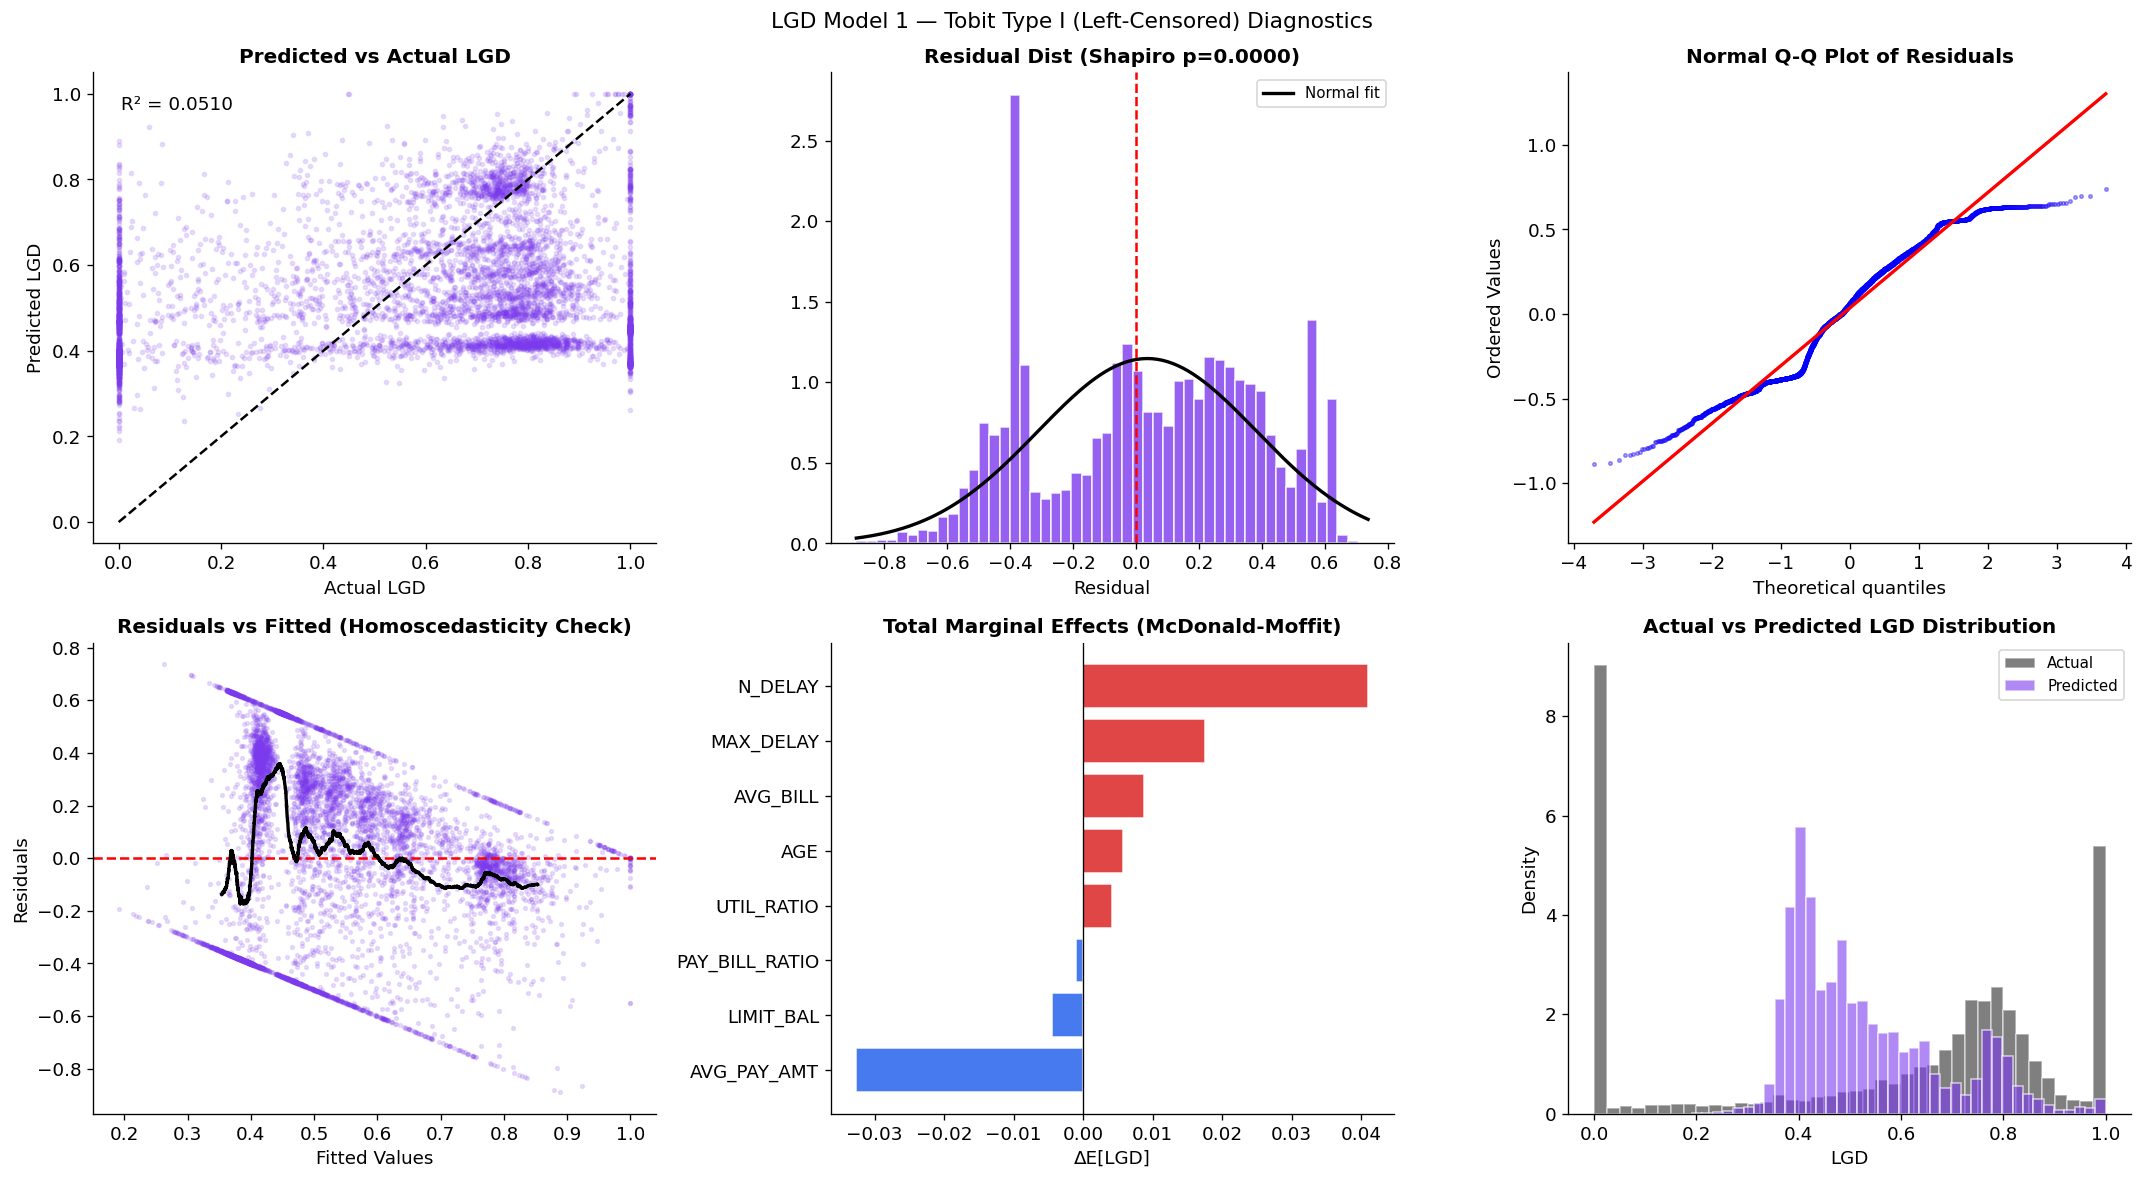

Tobit I  —  RMSE: 0.34952  |  MAE: 0.29895  |  R²: 0.05102
Log-Likelihood  : 15773.48  |  AIC: 31566.95  |  BIC: 31650.04


In [15]:
# ─── Tobit 1 Diagnostics ─────────────────────────────────────────────────────
def_mask    = df['DEFAULT'] == 1
actual_lgd  = df.loc[def_mask, 'LGD_proxy'].values
pred_t1     = df.loc[def_mask, 'LGD_pred_tobit1'].values
resid_t1    = actual_lgd - pred_t1

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LGD Model 1 — Tobit Type I (Left-Censored) Diagnostics', fontsize=13)

# 1. Predicted vs Actual
ax = axes[0, 0]
ax.scatter(actual_lgd, pred_t1, alpha=0.15, s=6, color=C['tobit1'])
ax.plot([0,1],[0,1],'k--', lw=1.5)
r2_t1 = 1 - np.sum(resid_t1**2) / np.sum((actual_lgd - actual_lgd.mean())**2)
ax.text(0.05, 0.92, f'R² = {r2_t1:.4f}', transform=ax.transAxes)
ax.set_xlabel('Actual LGD'); ax.set_ylabel('Predicted LGD')
ax.set_title('Predicted vs Actual LGD')

# 2. Residual Distribution
ax = axes[0, 1]
ax.hist(resid_t1, bins=50, color=C['tobit1'], alpha=0.8, density=True, edgecolor='white')
xr = np.linspace(resid_t1.min(), resid_t1.max(), 200)
ax.plot(xr, norm.pdf(xr, resid_t1.mean(), resid_t1.std()), 'k-', lw=2, label='Normal fit')
ax.axvline(0, color='red', lw=1.5, linestyle='--')
stat_sw, p_sw = shapiro(resid_t1[:2000])  # Shapiro (max 5000 obs)
ax.set_title(f'Residual Dist (Shapiro p={p_sw:.4f})')
ax.set_xlabel('Residual'); ax.legend(fontsize=9)

# 3. Q-Q Plot
ax = axes[0, 2]
stats.probplot(resid_t1, dist='norm', plot=ax)
ax.set_title('Normal Q-Q Plot of Residuals')
ax.get_lines()[0].set(markerfacecolor=C['tobit1'], markersize=2, alpha=0.4)
ax.get_lines()[1].set(color='red', lw=2)

# 4. Residuals vs Fitted
ax = axes[1, 0]
ax.scatter(pred_t1, resid_t1, alpha=0.15, s=5, color=C['tobit1'])
ax.axhline(0, color='red', lw=1.5, linestyle='--')
# LOESS-like smoothed line
sort_idx = np.argsort(pred_t1)
window   = len(pred_t1)//20
smooth_y = pd.Series(resid_t1[sort_idx]).rolling(window, center=True).mean().values
ax.plot(pred_t1[sort_idx], smooth_y, 'k-', lw=2)
ax.set_xlabel('Fitted Values'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted (Homoscedasticity Check)')

# 5. Marginal Effects
ax = axes[1, 1]
me_plot = me1[me1['Variable'] != 'const'].sort_values('ME_total')
colors_me = [C['lgd'] if v > 0 else C['pd'] for v in me_plot['ME_total']]
ax.barh(me_plot['Variable'], me_plot['ME_total'],
        color=colors_me, alpha=0.85, edgecolor='white')
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Total Marginal Effects (McDonald-Moffit)')
ax.set_xlabel('ΔE[LGD]')

# 6. Predicted LGD distribution
ax = axes[1, 2]
ax.hist(actual_lgd, bins=40, alpha=0.5, density=True,
        color='black', label='Actual', edgecolor='white')
ax.hist(pred_t1, bins=40, alpha=0.6, density=True,
        color=C['tobit1'], label='Predicted', edgecolor='white')
ax.set_title('Actual vs Predicted LGD Distribution')
ax.set_xlabel('LGD'); ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('tobit1_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
rmse_t1 = np.sqrt(np.mean(resid_t1**2))
mae_t1  = np.mean(np.abs(resid_t1))
print(f"Tobit I  —  RMSE: {rmse_t1:.5f}  |  MAE: {mae_t1:.5f}  |  R²: {r2_t1:.5f}")
print(f"Log-Likelihood  : {-tobit1_result.llf:.2f}  |  AIC: {tobit1_result.aic:.2f}  |  BIC: {tobit1_result.bic:.2f}")

## 5. LGD Model 2 — Two-Limit Tobit (Censored at 0 AND 1)

When LGD has **mass at both 0 and 1**, a left-censored-only Tobit is misspecified.  
The Two-Limit (Double-Censored) Tobit uses:

```
y_i = 0       if y*_i ≤ 0     (left-censored  — full recovery)
y_i = y*_i    if 0 < y*_i < 1 (interior)
y_i = 1       if y*_i ≥ 1     (right-censored — total loss)

ln L = Σ_{y=0} ln Φ(-Xβ/σ)  +  Σ_{0<y<1} ln φ((y-Xβ)/σ)/σ  +  Σ_{y=1} ln[1 - Φ((1-Xβ)/σ)]
```

In [16]:
class TobitTwoLimit(GenericLikelihoodModel):
    """
    Two-Limit (Double-Censored) Tobit — censored at L=0 and U=1.
    left_cens  : bool array, True when y = 0 (left-censored)
    right_cens : bool array, True when y = 1 (right-censored)
    interior   : bool array, True when 0 < y < 1
    """
    def __init__(self, endog, exog, left_cens, right_cens, **kwds):
        super().__init__(endog, exog, **kwds)
        self.left_cens  = np.asarray(left_cens,  dtype=bool)
        self.right_cens = np.asarray(right_cens, dtype=bool)
        self.interior   = ~(self.left_cens | self.right_cens)

    def nloglikeobs(self, params):
        beta  = params[:-1]
        sigma = np.exp(params[-1])
        xb    = self.exog @ beta
        y     = self.endog

        nll = np.zeros(len(y))

        # Left-censored (y = 0):
        if self.left_cens.any():
            nll[self.left_cens] = -norm.logcdf(-xb[self.left_cens] / sigma)

        # Right-censored (y = 1):
        if self.right_cens.any():
            nll[self.right_cens] = -norm.logsf((1 - xb[self.right_cens]) / sigma)

        # Interior (0 < y < 1):
        if self.interior.any():
            resid = (y[self.interior] - xb[self.interior]) / sigma
            nll[self.interior] = -(norm.logpdf(resid) - np.log(sigma))

        return nll

    def fit(self, start_params=None, method='bfgs', maxiter=1000, **kwds):
        if start_params is None:
            idx = self.interior
            if idx.sum() > 10:
                ols = OLS(self.endog[idx], self.exog[idx]).fit()
                start_params = np.append(ols.params, np.log(max(ols.resid.std(), 0.01)))
            else:
                start_params = np.zeros(self.exog.shape[1] + 1)
                start_params[-1] = np.log(0.3)
        return super().fit(start_params=start_params, method=method,
                           maxiter=maxiter, **kwds)

print("TobitTwoLimit class defined.")

TobitTwoLimit class defined.


In [17]:
# ─── Two-Limit Tobit uses defaulters ONLY ─────────────────────────────────────
# We model on defaulters where LGD may be 0, (0,1), or 1
# Non-defaulters are excluded (no LGD observed)

scaler_t2  = StandardScaler()
X_t2_raw   = pd.DataFrame(
    scaler_t2.fit_transform(defaulters[tobit_features]), columns=tobit_features
)
X_t2       = sm.add_constant(X_t2_raw)
y_t2       = defaulters['LGD_proxy'].values

left_cens2  = (y_t2 == 0.0)          # LGD = 0 → left-censored
right_cens2 = (y_t2 == 1.0)          # LGD = 1 → right-censored

print(f"Two-Limit Tobit — sample: defaulters only")
print(f"  Left-censored  (LGD = 0) : {left_cens2.sum():>6,}  ({left_cens2.mean():.2%})")
print(f"  Right-censored (LGD = 1) : {right_cens2.sum():>6,}  ({right_cens2.mean():.2%})")
print(f"  Interior (0 < LGD < 1)  : {(~(left_cens2|right_cens2)).sum():>6,}  ({(~(left_cens2|right_cens2)).mean():.2%})")
print(f"  Total                    : {len(y_t2):>6,}")
print()

tobit2        = TobitTwoLimit(y_t2, X_t2.values, left_cens2, right_cens2)
tobit2_result = tobit2.fit(disp=False)
print(tobit2_result.summary(xname=X_t2.columns.tolist() + ['log_sigma']))

Two-Limit Tobit — sample: defaulters only
  Left-censored  (LGD = 0) :  1,480  (22.30%)
  Right-censored (LGD = 1) :    870  (13.11%)
  Interior (0 < LGD < 1)  :  4,286  (64.59%)
  Total                    :  6,636

                            TobitTwoLimit Results                             
Dep. Variable:                      y   Log-Likelihood:                -5009.8
Model:                  TobitTwoLimit   AIC:                         1.004e+04
Method:            Maximum Likelihood   BIC:                         1.011e+04
Date:                Wed, 22 Apr 2026                                         
Time:                        11:00:21                                         
No. Observations:                6636                                         
Df Residuals:                    6627                                         
Df Model:                           8                                         
                     coef    std err          z      P>|z|      [0.025   

In [18]:
# ─── Two-Limit Tobit Predictions ─────────────────────────────────────────────
def tobit2_predict(result, X):
    """
    E[y | X] for Two-Limit Tobit:
    E[y] = Φ(z_L) * 0 + [Φ(z_U) - Φ(z_L)] * E[y*|z_L < y* < z_U] + [1-Φ(z_U)] * 1
    """
    params = result.params
    beta   = params[:-1]
    sigma  = np.exp(params[-1])
    xb     = X @ beta
    z_L    = -xb / sigma              # z for lower limit (0)
    z_U    = (1 - xb) / sigma        # z for upper limit (1)

    # Prob in each region
    P_left  = norm.cdf(z_L)
    P_right = 1 - norm.cdf(z_U)
    P_mid   = norm.cdf(z_U) - norm.cdf(z_L)

    # Conditional mean in interior (truncated normal)
    denom   = np.where(P_mid > 1e-12, P_mid, 1e-12)
    E_mid   = xb + sigma * (norm.pdf(z_L) - norm.pdf(z_U)) / denom

    # Unconditional E[y]
    E_y = P_left * 0 + P_mid * E_mid + P_right * 1
    return np.clip(E_y, 0, 1)

# Predict on defaulters
pred_t2_def = tobit2_predict(tobit2_result, X_t2.values)
defaulters  = defaulters.copy()
defaulters['LGD_pred_tobit2'] = pred_t2_def

# For full df (predict using scaled defaulter features, then merge)
X_full_t2 = pd.DataFrame(
    scaler_t2.transform(df[tobit_features]), columns=tobit_features
)
X_full_t2 = sm.add_constant(X_full_t2)
df['LGD_pred_tobit2'] = tobit2_predict(tobit2_result, X_full_t2.values)

# Marginal effects (Two-Limit Tobit)
def tobit2_marginal_effects(result, X, feature_names):
    params = result.params
    beta   = params[:-1]
    sigma  = np.exp(params[-1])
    xb     = X @ beta
    z_L    = -xb / sigma
    z_U    = (1 - xb) / sigma

    # Average ∂E[y]/∂x = β × [Φ(z_U) - Φ(z_L)]  (unconditional)
    scale = (norm.cdf(z_U) - norm.cdf(z_L)).mean()
    rows = []
    for i, name in enumerate(feature_names):
        rows.append({
            'Variable':  name,
            'Coeff':     round(beta[i], 5),
            'ME_total':  round(beta[i] * scale, 5)
        })
    return pd.DataFrame(rows)

me2 = tobit2_marginal_effects(tobit2_result, X_t2.values, X_t2.columns.tolist())
print("=" * 50)
print("TWO-LIMIT TOBIT — MARGINAL EFFECTS")
print("=" * 50)
print(me2.to_string(index=False))

TWO-LIMIT TOBIT — MARGINAL EFFECTS
      Variable    Coeff  ME_total
         const  0.52563   0.35636
     LIMIT_BAL  0.10110   0.06854
           AGE  0.00994   0.00674
    UTIL_RATIO  0.10544   0.07149
     MAX_DELAY  0.05045   0.03421
       N_DELAY  0.02701   0.01831
PAY_BILL_RATIO -0.02328  -0.01578
      AVG_BILL  0.12581   0.08529
   AVG_PAY_AMT -0.29275  -0.19848


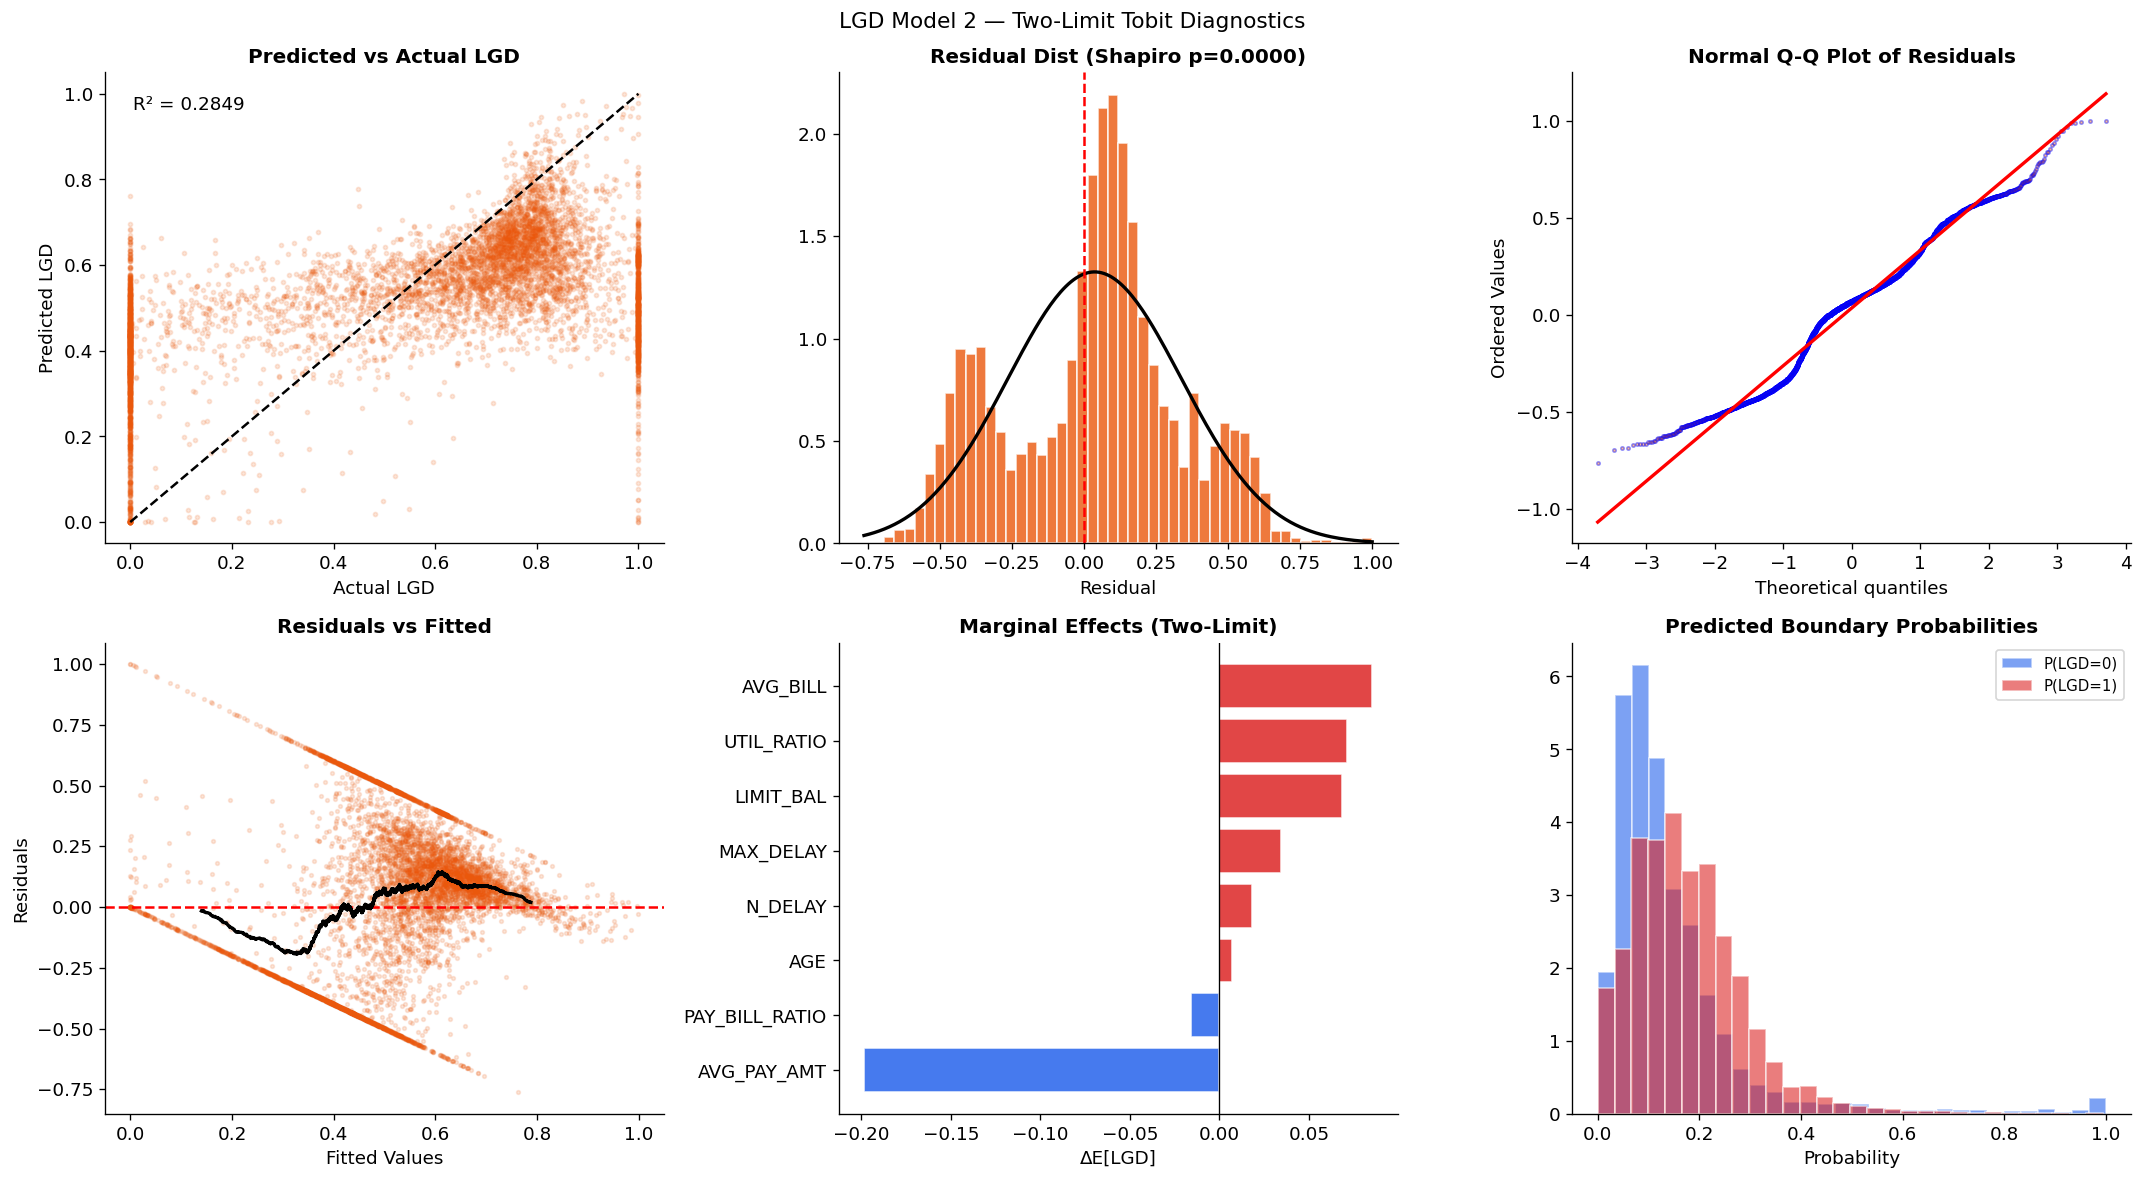

Two-Limit Tobit —  RMSE: 0.30341  |  MAE: 0.24398  |  R²: 0.28485
Log-Likelihood     : 5009.84  |  AIC: 10039.69  |  BIC: 10107.69


In [19]:
# ─── Two-Limit Tobit Diagnostics ─────────────────────────────────────────────
actual_lgd2 = y_t2
resid_t2    = actual_lgd2 - pred_t2_def

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LGD Model 2 — Two-Limit Tobit Diagnostics', fontsize=13)

# 1. Predicted vs Actual
ax = axes[0, 0]
ax.scatter(actual_lgd2, pred_t2_def, alpha=0.15, s=6, color=C['tobit2'])
ax.plot([0,1],[0,1],'k--', lw=1.5)
r2_t2 = 1 - np.sum(resid_t2**2) / np.sum((actual_lgd2 - actual_lgd2.mean())**2)
ax.text(0.05, 0.92, f'R² = {r2_t2:.4f}', transform=ax.transAxes)
ax.set_xlabel('Actual LGD'); ax.set_ylabel('Predicted LGD')
ax.set_title('Predicted vs Actual LGD')

# 2. Residual Distribution
ax = axes[0, 1]
ax.hist(resid_t2, bins=50, color=C['tobit2'], alpha=0.8, density=True, edgecolor='white')
xr = np.linspace(resid_t2.min(), resid_t2.max(), 200)
ax.plot(xr, norm.pdf(xr, resid_t2.mean(), resid_t2.std()), 'k-', lw=2)
ax.axvline(0, color='red', lw=1.5, linestyle='--')
stat_sw2, p_sw2 = shapiro(resid_t2[:2000])
ax.set_title(f'Residual Dist (Shapiro p={p_sw2:.4f})')
ax.set_xlabel('Residual')

# 3. Q-Q Plot
ax = axes[0, 2]
stats.probplot(resid_t2, dist='norm', plot=ax)
ax.set_title('Normal Q-Q Plot of Residuals')
ax.get_lines()[0].set(markerfacecolor=C['tobit2'], markersize=2, alpha=0.4)
ax.get_lines()[1].set(color='red', lw=2)

# 4. Residuals vs Fitted
ax = axes[1, 0]
ax.scatter(pred_t2_def, resid_t2, alpha=0.15, s=5, color=C['tobit2'])
ax.axhline(0, color='red', lw=1.5, linestyle='--')
sort_idx2 = np.argsort(pred_t2_def)
window2   = max(len(pred_t2_def)//20, 10)
smooth_y2 = pd.Series(resid_t2[sort_idx2]).rolling(window2, center=True).mean().values
ax.plot(pred_t2_def[sort_idx2], smooth_y2, 'k-', lw=2)
ax.set_xlabel('Fitted Values'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')

# 5. Marginal Effects
ax = axes[1, 1]
me_plot2 = me2[me2['Variable'] != 'const'].sort_values('ME_total')
colors_me2 = [C['lgd'] if v > 0 else C['pd'] for v in me_plot2['ME_total']]
ax.barh(me_plot2['Variable'], me_plot2['ME_total'],
        color=colors_me2, alpha=0.85, edgecolor='white')
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Marginal Effects (Two-Limit)')
ax.set_xlabel('ΔE[LGD]')

# 6. Boundary probability
ax = axes[1, 2]
params2 = tobit2_result.params
beta2   = params2[:-1]
sigma2  = np.exp(params2[-1])
xb2     = X_t2.values @ beta2
p_left  = norm.cdf(-xb2 / sigma2)
p_right = 1 - norm.cdf((1 - xb2) / sigma2)
ax.hist(p_left,  bins=30, alpha=0.6, density=True, color=C['pd'],  label='P(LGD=0)', edgecolor='white')
ax.hist(p_right, bins=30, alpha=0.6, density=True, color=C['lgd'], label='P(LGD=1)', edgecolor='white')
ax.set_title('Predicted Boundary Probabilities')
ax.set_xlabel('Probability'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('tobit2_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

rmse_t2 = np.sqrt(np.mean(resid_t2**2))
mae_t2  = np.mean(np.abs(resid_t2))
print(f"Two-Limit Tobit —  RMSE: {rmse_t2:.5f}  |  MAE: {mae_t2:.5f}  |  R²: {r2_t2:.5f}")
print(f"Log-Likelihood     : {-tobit2_result.llf:.2f}  |  AIC: {tobit2_result.aic:.2f}  |  BIC: {tobit2_result.bic:.2f}")

## 6. LGD Model 3 — Heckman's Tobit (Selection Model)

Heckman separates two distinct processes:
- **Stage 1 — Selection (Probit):** What predicts whether a client defaults at all?
- **Stage 2 — Outcome (OLS + IMR):** Given default, what determines the LGD severity?

The **Inverse Mills Ratio (IMR)** λ corrects for selection bias.

In [20]:
# ─── Stage 1: Probit Selection Equation ──────────────────────────────────────
selection_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO', 'MAX_DELAY', 'N_DELAY',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]

scaler_h = StandardScaler()
X_sel    = pd.DataFrame(
    scaler_h.fit_transform(df[selection_features]), columns=selection_features
)
X_sel_c  = sm.add_constant(X_sel)

probit_sel = sm.Probit(df['DEFAULT'], X_sel_c).fit(disp=False)
print("STAGE 1 — Probit Selection Equation:")
print(probit_sel.summary())

STAGE 1 — Probit Selection Equation:
                          Probit Regression Results                           
Dep. Variable:                DEFAULT   No. Observations:                30000
Model:                         Probit   Df Residuals:                    29991
Method:                           MLE   Df Model:                            8
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1406
Time:                        11:04:34   Log-Likelihood:                -13623.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.8534      0.009    -96.335      0.000      -0.871      -0.836
LIMIT_BAL         -0.0876      0.014     -6.364      0.000      -0.115      -0.061

In [21]:
# ─── Inverse Mills Ratio ─────────────────────────────────────────────────────
xg  = X_sel_c.values @ probit_sel.params.values
imr = norm.pdf(xg) / np.where(norm.cdf(xg) > 1e-12, norm.cdf(xg), 1e-12)
df['IMR'] = imr

print("IMR Summary (all observations):")
print(pd.Series(imr).describe().round(4))
print(f"\nIMR for defaulters   : {imr[df['DEFAULT']==1].mean():.4f} (mean)")
print(f"IMR for non-defaulters: {imr[df['DEFAULT']==0].mean():.4f} (mean)")

IMR Summary (all observations):
count    30000.0000
mean         1.4307
std          0.3839
min          0.0000
25%          1.2465
50%          1.5536
75%          1.6558
max          6.4928
dtype: float64

IMR for defaulters   : 1.1438 (mean)
IMR for non-defaulters: 1.5122 (mean)


In [22]:
# ─── Stage 2: OLS Outcome Equation (defaulters only + IMR) ───────────────────
# Exclusion restriction: N_DELAY, MAX_DELAY excluded from outcome eq
outcome_features = [
    'LIMIT_BAL', 'AGE', 'UTIL_RATIO',
    'PAY_BILL_RATIO', 'AVG_BILL', 'AVG_PAY_AMT'
]

def_idx  = df['DEFAULT'] == 1
scaler_h2 = StandardScaler()
X_out    = pd.DataFrame(
    scaler_h2.fit_transform(df.loc[def_idx, outcome_features]),
    columns=outcome_features
)
X_out['IMR'] = df.loc[def_idx, 'IMR'].values
X_out        = sm.add_constant(X_out)
y_out        = df.loc[def_idx, 'LGD_proxy'].values

heckman_result = OLS(y_out, X_out).fit(cov_type='HC3')  # Heteroskedasticity-robust SE
print("STAGE 2 — OLS Outcome Equation (with IMR):")
print(heckman_result.summary())

print("\n" + "="*55)
imr_coef  = heckman_result.params['IMR']
imr_pval  = heckman_result.pvalues['IMR']
print(f"IMR Coefficient : {imr_coef:.5f}")
print(f"IMR p-value     : {imr_pval:.4f}")
if imr_pval < 0.05:
    print("→ SIGNIFICANT: Selection bias is present. Heckman correction is necessary.")
else:
    print("→ NOT SIGNIFICANT: No strong evidence of selection bias.")

STAGE 2 — OLS Outcome Equation (with IMR):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     205.1
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.69e-276
Time:                        11:04:42   Log-Likelihood:                -1693.4
No. Observations:                6636   AIC:                             3403.
Df Residuals:                    6628   BIC:                             3457.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
c

In [23]:
# ─── Heckman Predictions ─────────────────────────────────────────────────────
X_all_out = pd.DataFrame(
    scaler_h2.transform(df[outcome_features]), columns=outcome_features
)
X_all_out['IMR'] = df['IMR'].values
X_all_out        = sm.add_constant(X_all_out)
df['LGD_pred_heckman'] = np.clip(heckman_result.predict(X_all_out), 0, 1)

pred_heck = df.loc[def_idx, 'LGD_pred_heckman'].values
resid_h   = y_out - pred_heck

# ─── Breusch-Pagan Heteroskedasticity Test ────────────────────────────────────
bp_stat, bp_pval, _, _ = het_breuschpagan(heckman_result.resid, X_out)
dw_stat = durbin_watson(heckman_result.resid)

print("=" * 55)
print("HECKMAN STAGE 2 — OLS SPECIFICATION TESTS")
print("=" * 55)
print(f"  Breusch-Pagan (heteroskedasticity):")
print(f"    LM Statistic = {bp_stat:.4f}  |  p-value = {bp_pval:.4f}")
print(f"  Durbin-Watson (autocorrelation)   : {dw_stat:.4f}")
stat_sw_h, p_sw_h = shapiro(resid_h[:2000])
print(f"  Shapiro-Wilk (normality of resid) : W={stat_sw_h:.4f}  p={p_sw_h:.4f}")

# VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_out.columns
vif_data['VIF']     = [variance_inflation_factor(X_out.values, i)
                       for i in range(X_out.shape[1])]
print("\nVariance Inflation Factors (VIF > 10 → multicollinearity concern):")
print(vif_data.to_string(index=False))

HECKMAN STAGE 2 — OLS SPECIFICATION TESTS
  Breusch-Pagan (heteroskedasticity):
    LM Statistic = 2413.0609  |  p-value = 0.0000
  Durbin-Watson (autocorrelation)   : 1.9921
  Shapiro-Wilk (normality of resid) : W=0.9737  p=0.0000

Variance Inflation Factors (VIF > 10 → multicollinearity concern):
       Feature      VIF
         const 9.709657
     LIMIT_BAL 2.357488
           AGE 1.038591
    UTIL_RATIO 2.596638
PAY_BILL_RATIO 1.008979
      AVG_BILL 2.876840
   AVG_PAY_AMT 1.492920
           IMR 1.344330


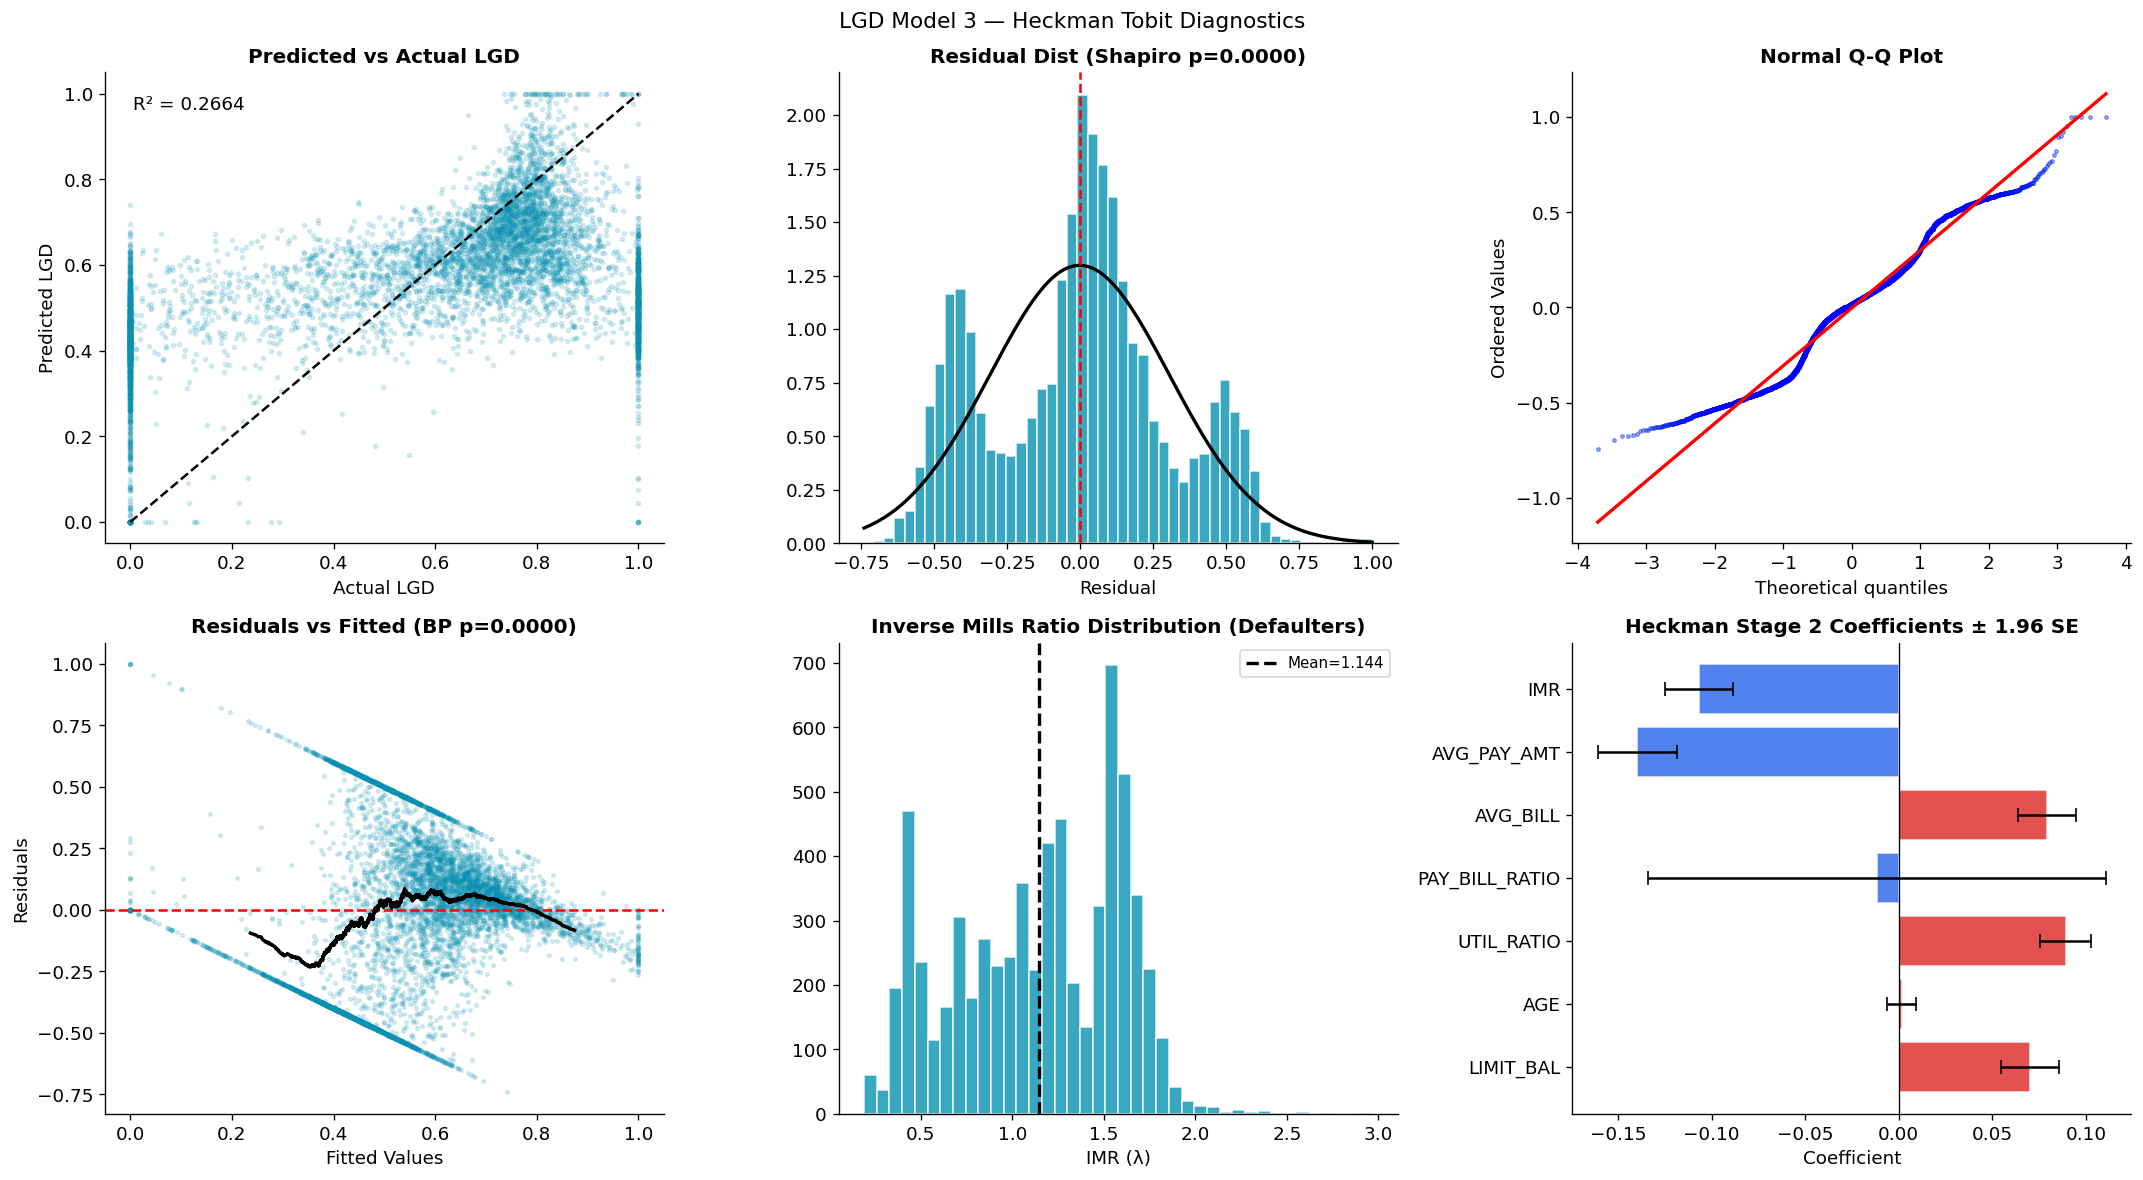

Heckman  —  RMSE: 0.30730  |  MAE: 0.24299  |  R²: 0.26641
R² (Stage 2 OLS) : 0.24229  |  Adj R²: 0.24149


In [24]:
# ─── Heckman Diagnostics ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LGD Model 3 — Heckman Tobit Diagnostics', fontsize=13)

# 1. Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y_out, pred_heck, alpha=0.15, s=6, color=C['heckman'])
ax.plot([0,1],[0,1],'k--', lw=1.5)
r2_h = 1 - np.sum(resid_h**2) / np.sum((y_out - y_out.mean())**2)
ax.text(0.05, 0.92, f'R² = {r2_h:.4f}', transform=ax.transAxes)
ax.set_xlabel('Actual LGD'); ax.set_ylabel('Predicted LGD')
ax.set_title('Predicted vs Actual LGD')

# 2. Residual Distribution
ax = axes[0, 1]
ax.hist(resid_h, bins=50, color=C['heckman'], alpha=0.8, density=True, edgecolor='white')
xr = np.linspace(resid_h.min(), resid_h.max(), 200)
ax.plot(xr, norm.pdf(xr, resid_h.mean(), resid_h.std()), 'k-', lw=2)
ax.axvline(0, color='red', lw=1.5, linestyle='--')
ax.set_title(f'Residual Dist (Shapiro p={p_sw_h:.4f})')
ax.set_xlabel('Residual')

# 3. Q-Q Plot
ax = axes[0, 2]
stats.probplot(resid_h, dist='norm', plot=ax)
ax.set_title('Normal Q-Q Plot')
ax.get_lines()[0].set(markerfacecolor=C['heckman'], markersize=2, alpha=0.4)
ax.get_lines()[1].set(color='red', lw=2)

# 4. Residuals vs Fitted (Heteroskedasticity)
ax = axes[1, 0]
ax.scatter(pred_heck, resid_h, alpha=0.15, s=5, color=C['heckman'])
ax.axhline(0, color='red', lw=1.5, linestyle='--')
sort_idxh = np.argsort(pred_heck)
windowh   = max(len(pred_heck)//20, 10)
smooth_yh = pd.Series(resid_h[sort_idxh]).rolling(windowh, center=True).mean().values
ax.plot(pred_heck[sort_idxh], smooth_yh, 'k-', lw=2)
ax.set_xlabel('Fitted Values'); ax.set_ylabel('Residuals')
ax.set_title(f'Residuals vs Fitted (BP p={bp_pval:.4f})')

# 5. IMR Distribution
ax = axes[1, 1]
imr_def = df.loc[def_idx, 'IMR'].values
ax.hist(imr_def, bins=40, color=C['heckman'], alpha=0.8, edgecolor='white')
ax.axvline(imr_def.mean(), color='k', lw=2, linestyle='--',
           label=f'Mean={imr_def.mean():.3f}')
ax.set_title('Inverse Mills Ratio Distribution (Defaulters)')
ax.set_xlabel('IMR (λ)'); ax.legend(fontsize=9)

# 6. Coefficient plot
ax = axes[1, 2]
coef_h = heckman_result.params.drop('const')
se_h   = heckman_result.bse.drop('const')
colors_h = [C['lgd'] if c > 0 else C['pd'] for c in coef_h]
ax.barh(coef_h.index, coef_h.values,
        xerr=1.96*se_h.values, color=colors_h, alpha=0.8, capsize=4, edgecolor='white')
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Heckman Stage 2 Coefficients ± 1.96 SE')
ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('heckman_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

rmse_h = np.sqrt(np.mean(resid_h**2))
mae_h  = np.mean(np.abs(resid_h))
print(f"Heckman  —  RMSE: {rmse_h:.5f}  |  MAE: {mae_h:.5f}  |  R²: {r2_h:.5f}")
print(f"R² (Stage 2 OLS) : {heckman_result.rsquared:.5f}  |  Adj R²: {heckman_result.rsquared_adj:.5f}")

## 7. Model Comparison — All Three LGD Models

In [25]:
# ─── Comparison (all evaluated on defaulters where actual LGD is known) ───────
actual   = df.loc[def_mask, 'LGD_proxy'].values
pred_t1_ = df.loc[def_mask, 'LGD_pred_tobit1'].values
pred_t2_ = df.loc[def_mask, 'LGD_pred_tobit2'].values
pred_h_  = df.loc[def_mask, 'LGD_pred_heckman'].values

# Naive benchmarks
pred_mean = np.full(def_mask.sum(), actual.mean())

def rmse(y, yh): return np.sqrt(np.mean((y-yh)**2))
def mae(y, yh):  return np.mean(np.abs(y-yh))
def r2(y, yh):   return 1 - np.sum((y-yh)**2)/np.sum((y-y.mean())**2)

comparison = pd.DataFrame({
    'Model'   : ['Tobit I (Left-Censored)', 'Two-Limit Tobit', 'Heckman Tobit', 'Naive Mean'],
    'RMSE'    : [rmse(actual,pred_t1_), rmse(actual,pred_t2_), rmse(actual,pred_h_), rmse(actual,pred_mean)],
    'MAE'     : [mae(actual,pred_t1_),  mae(actual,pred_t2_),  mae(actual,pred_h_),  mae(actual,pred_mean)],
    'R²'      : [r2(actual,pred_t1_),   r2(actual,pred_t2_),   r2(actual,pred_h_),   r2(actual,pred_mean)],
    'AIC'     : [tobit1_result.aic,      tobit2_result.aic,      np.nan,              np.nan],
    'BIC'     : [tobit1_result.bic,      tobit2_result.bic,      np.nan,              np.nan],
    'Mean Pred': [pred_t1_.mean(),       pred_t2_.mean(),        pred_h_.mean(),      pred_mean.mean()]
}).set_index('Model').round(5)

print("=" * 85)
print("FULL LGD MODEL COMPARISON (evaluated on defaulters)")
print("=" * 85)
print(comparison.to_string())
print()
print(f"Actual LGD mean (defaulters): {actual.mean():.5f}")

FULL LGD MODEL COMPARISON (evaluated on defaulters)
                            RMSE      MAE       R²          AIC          BIC  Mean Pred
Model                                                                                  
Tobit I (Left-Censored)  0.34952  0.29895  0.05102  31566.95308  31650.04261    0.52853
Two-Limit Tobit          0.30341  0.24398  0.28485  10039.68982  10107.69247    0.52680
Heckman Tobit            0.30730  0.24299  0.26641          NaN          NaN    0.56661
Naive Mean               0.35879  0.31085  0.00000          NaN          NaN    0.56424

Actual LGD mean (defaulters): 0.56424


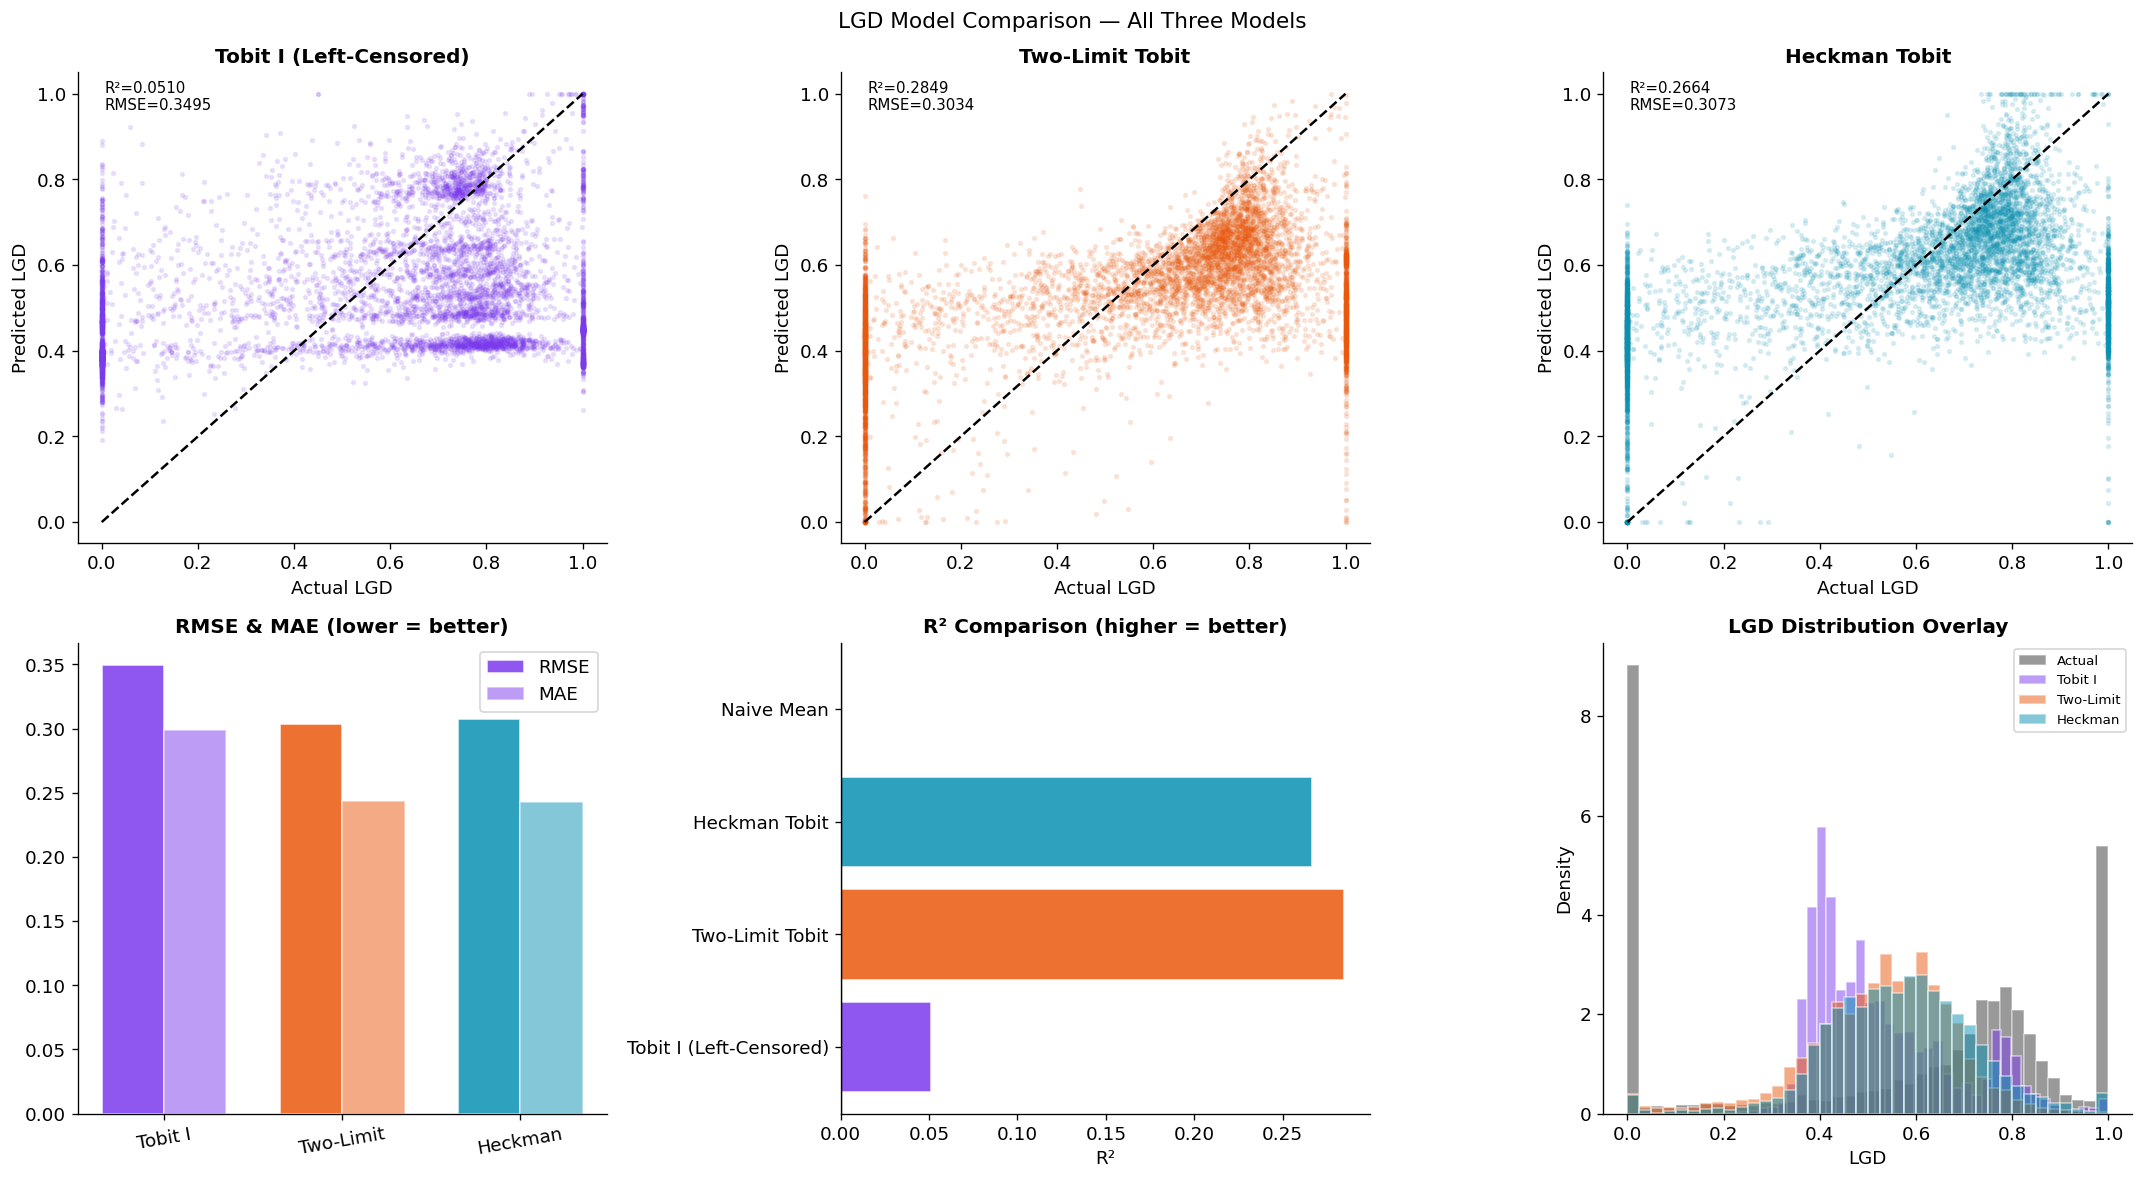

In [26]:
# ─── Model Comparison Visuals ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LGD Model Comparison — All Three Models', fontsize=13)

models_info = [
    ('Tobit I (Left-Censored)', pred_t1_, C['tobit1']),
    ('Two-Limit Tobit',         pred_t2_, C['tobit2']),
    ('Heckman Tobit',           pred_h_,  C['heckman'])
]

# 1-3. Predicted vs Actual for each model
for i, (name, pred, col) in enumerate(models_info):
    ax = axes[0, i]
    ax.scatter(actual, pred, alpha=0.12, s=5, color=col)
    ax.plot([0,1],[0,1],'k--', lw=1.5)
    r2_val = r2(actual, pred)
    rmse_val = rmse(actual, pred)
    ax.text(0.05, 0.92, f'R²={r2_val:.4f}\nRMSE={rmse_val:.4f}',
            transform=ax.transAxes, fontsize=9)
    ax.set_title(name)
    ax.set_xlabel('Actual LGD'); ax.set_ylabel('Predicted LGD')

# 4. RMSE / MAE Grouped Bar
ax = axes[1, 0]
comp_models = comparison[comparison.index != 'Naive Mean']
x = np.arange(len(comp_models))
w = 0.35
ax.bar(x - w/2, comp_models['RMSE'], width=w, label='RMSE',
       color=[C['tobit1'], C['tobit2'], C['heckman']], alpha=0.85, edgecolor='white')
ax.bar(x + w/2, comp_models['MAE'],  width=w, label='MAE',
       color=[C['tobit1'], C['tobit2'], C['heckman']], alpha=0.5, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Tobit I', 'Two-Limit', 'Heckman'], rotation=10)
ax.set_title('RMSE & MAE (lower = better)')
ax.legend()

# 5. R² Comparison
ax = axes[1, 1]
all_models = comparison.index.tolist()
r2_vals    = comparison['R²'].values
colors_r2  = [C['tobit1'], C['tobit2'], C['heckman'], C['neutral']]
ax.barh(all_models, r2_vals, color=colors_r2, alpha=0.85, edgecolor='white')
ax.axvline(0, color='k', lw=0.8)
ax.set_title('R² Comparison (higher = better)')
ax.set_xlabel('R²')

# 6. Distribution overlay
ax = axes[1, 2]
ax.hist(actual,   bins=40, alpha=0.4, density=True, color='black',       label='Actual',   edgecolor='white')
ax.hist(pred_t1_, bins=40, alpha=0.5, density=True, color=C['tobit1'],   label='Tobit I',  edgecolor='white')
ax.hist(pred_t2_, bins=40, alpha=0.5, density=True, color=C['tobit2'],   label='Two-Limit',edgecolor='white')
ax.hist(pred_h_,  bins=40, alpha=0.5, density=True, color=C['heckman'],  label='Heckman',  edgecolor='white')
ax.set_title('LGD Distribution Overlay')
ax.set_xlabel('LGD'); ax.set_ylabel('Density')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Expected Loss = PD × LGD × EAD — All Three Models

In [36]:
df['EAD'] = df['LIMIT_BAL']   # EAD = credit limit

df['EL_tobit1']  = df['PD_logit'] * df['LGD_pred_tobit1']  * df['EAD']
df['EL_tobit2']  = df['PD_logit'] * df['LGD_pred_tobit2']  * df['EAD']
df['EL_heckman'] = df['PD_logit'] * df['LGD_pred_heckman'] * df['EAD']

tot_ead = df['EAD'].sum()

print("=" * 65)
print("PORTFOLIO EXPECTED LOSS SUMMARY")
print("=" * 65)
print(f"  Total Portfolio EAD                : NT$ {tot_ead:>18,.0f}")
print()
for model, el_col in [('Tobit I', 'EL_tobit1'), ('Two-Limit', 'EL_tobit2'), ('Heckman', 'EL_heckman')]:
    tot_el   = df[el_col].sum()
    mean_el  = df[el_col].mean()
    ratio    = tot_el / tot_ead
    print(f"  [{model}]")
    print(f"    Total EL                       : NT$ {tot_el:>15,.0f}")
    print(f"    Mean EL per client             : NT$ {mean_el:>15,.0f}")
    print(f"    Average EL / EAD (EL rate)     : {ratio:.4f}  ({ratio:.2%})")
    print(f"    Median EL per client           : NT$ {df[el_col].median():>15,.0f}")
    print(f"    EL at 99th percentile          : NT$ {df[el_col].quantile(0.99):>15,.0f}")
    print()

PORTFOLIO EXPECTED LOSS SUMMARY
  Total Portfolio EAD                : NT$      5,024,529,680

  [Tobit I]
    Total EL                       : NT$     420,668,448
    Mean EL per client             : NT$          14,022
    Average EL / EAD (EL rate)     : 0.0837  (8.37%)
    Median EL per client           : NT$           9,278
    EL at 99th percentile          : NT$          94,211

  [Two-Limit]
    Total EL                       : NT$     450,049,932
    Mean EL per client             : NT$          15,002
    Average EL / EAD (EL rate)     : 0.0896  (8.96%)
    Median EL per client           : NT$           9,283
    EL at 99th percentile          : NT$          94,710

  [Heckman]
    Total EL                       : NT$     487,069,073
    Mean EL per client             : NT$          16,236
    Average EL / EAD (EL rate)     : 0.0969  (9.69%)
    Median EL per client           : NT$          10,394
    EL at 99th percentile          : NT$         102,150



## 9. Portfolio Analysis — Concentration, Gini, HHI, and Risk Segmentation

In [37]:
# ─── Gini Coefficient (EL concentration) ─────────────────────────────────────
def gini_coefficient(arr):
    arr = np.sort(arr)
    n   = len(arr)
    idx = np.arange(1, n+1)
    return (2 * np.sum(idx * arr) / (n * arr.sum())) - (n+1)/n

# ─── HHI (Herfindahl-Hirschman Index) ────────────────────────────────────────
def hhi(arr):
    shares = arr / arr.sum()
    return (shares**2).sum()

# ─── Concentration stats ──────────────────────────────────────────────────────
print("=" * 70)
print("PORTFOLIO CONCENTRATION ANALYSIS")
print("=" * 70)
print(f"{'Metric':<40} {'Tobit I':>12} {'Two-Limit':>12} {'Heckman':>12}")
print("-" * 70)

for el_col, model_name in [('EL_tobit1','Tobit I'), ('EL_tobit2','Two-Limit'), ('EL_heckman','Heckman')]:
    el_vals = df[el_col].values
    # top-N EL shares
    df_sorted  = df.sort_values(el_col, ascending=False)
    top10_pct  = df_sorted.head(int(0.10*len(df)))[el_col].sum() / el_vals.sum()
    top20_pct  = df_sorted.head(int(0.20*len(df)))[el_col].sum() / el_vals.sum()
    gini_el    = gini_coefficient(el_vals)
    hhi_el     = hhi(el_vals)
    
    if el_col == 'EL_tobit1':
        # Print row headers
        print(f"  Average EL / EAD")
    print(f"  [{model_name}] EL/EAD            : {el_vals.sum()/df['EAD'].sum():.4%}")

print()
for metric_name, func in [('Gini Coeff (EL)', None), ('Top-10% share', None), ('Top-20% share', None), ('HHI (×10,000)', None)]:
    row = f"  {metric_name:<38}"
    for el_col in ['EL_tobit1', 'EL_tobit2', 'EL_heckman']:
        el_vals   = df[el_col].values
        df_sorted = df.sort_values(el_col, ascending=False)
        if 'Gini' in metric_name:
            val = gini_coefficient(el_vals)
            row += f" {val:>12.4f}"
        elif 'Top-10' in metric_name:
            val = df_sorted.head(int(0.10*len(df)))[el_col].sum() / el_vals.sum()
            row += f" {val:>12.2%}"
        elif 'Top-20' in metric_name:
            val = df_sorted.head(int(0.20*len(df)))[el_col].sum() / el_vals.sum()
            row += f" {val:>12.2%}"
        elif 'HHI' in metric_name:
            val = hhi(el_vals) * 10000
            row += f" {val:>12.4f}"
    print(row)

PORTFOLIO CONCENTRATION ANALYSIS
Metric                                        Tobit I    Two-Limit      Heckman
----------------------------------------------------------------------
  Average EL / EAD
  [Tobit I] EL/EAD            : 8.3723%
  [Two-Limit] EL/EAD            : 8.9571%
  [Heckman] EL/EAD            : 9.6938%

  Gini Coeff (EL)                              0.4962       0.5378       0.5234
  Top-10% share                                39.03%       39.21%       38.51%
  Top-20% share                                54.62%       56.75%       55.62%
  HHI (×10,000)                                0.9117       0.9096       0.8881


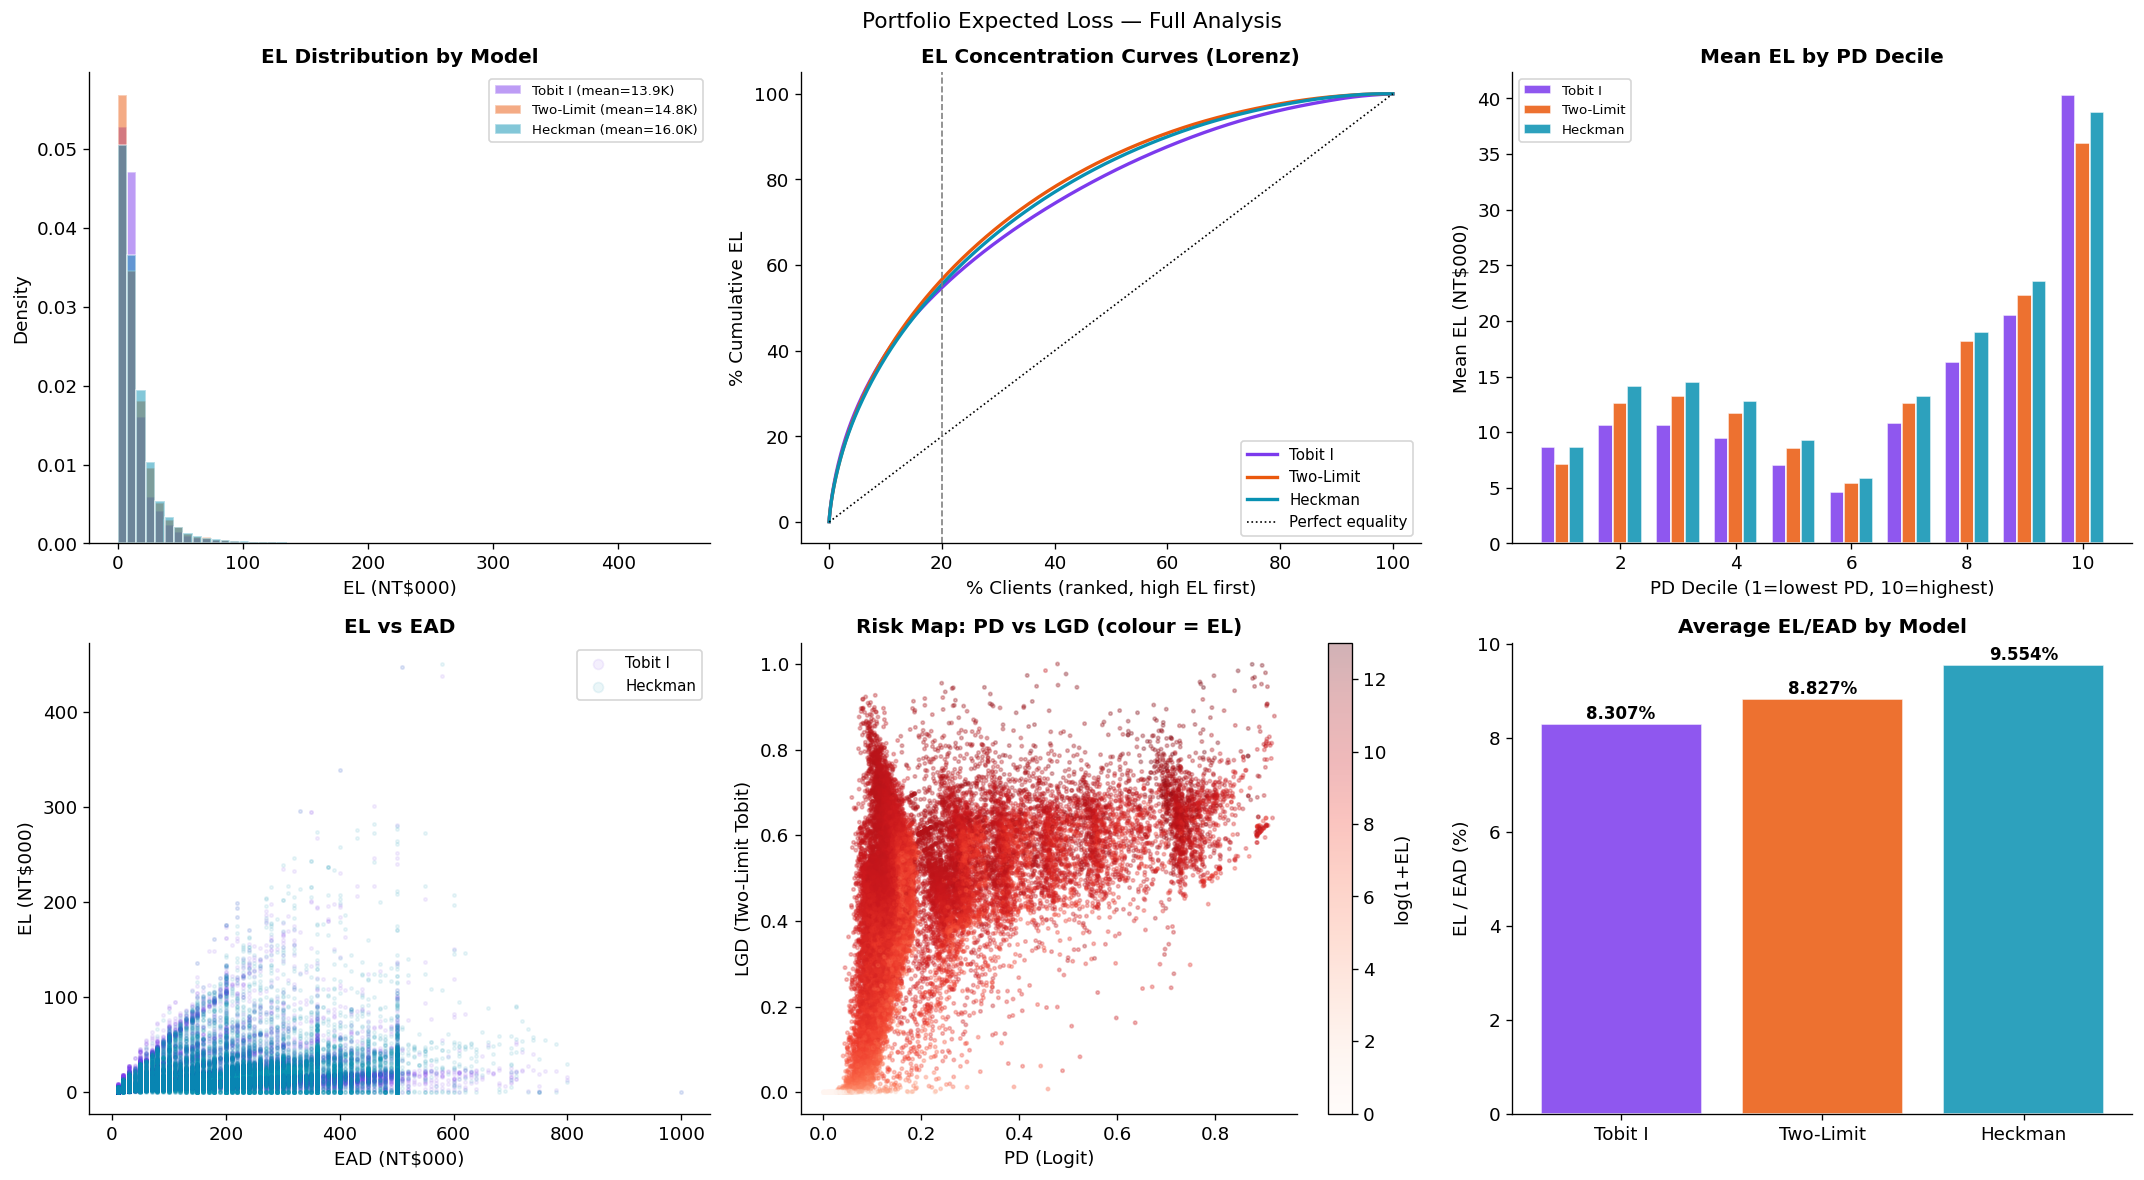

In [29]:
# ─── Full Portfolio Visuals ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Portfolio Expected Loss — Full Analysis', fontsize=13)

el_models = [
    ('EL_tobit1',  'Tobit I',     C['tobit1']),
    ('EL_tobit2',  'Two-Limit',   C['tobit2']),
    ('EL_heckman', 'Heckman',     C['heckman'])
]

# 1. EL Distribution comparison
ax = axes[0, 0]
for el_col, label, col in el_models:
    ax.hist(df[el_col]/1000, bins=60, alpha=0.5, density=True,
            color=col, label=f'{label} (mean={df[el_col].mean()/1000:.1f}K)', edgecolor='white')
ax.set_title('EL Distribution by Model')
ax.set_xlabel('EL (NT$000)'); ax.set_ylabel('Density')
ax.legend(fontsize=8)

# 2. Lorenz / Concentration Curves
ax = axes[0, 1]
for el_col, label, col in el_models:
    df_s    = df.sort_values(el_col, ascending=False)
    cum_el  = np.cumsum(df_s[el_col].values) / df[el_col].sum() * 100
    cum_pop = np.arange(1, len(df)+1) / len(df) * 100
    ax.plot(cum_pop, cum_el, color=col, lw=2, label=label)
ax.plot([0,100],[0,100],'k:', lw=1, label='Perfect equality')
ax.axvline(20, color='gray', linestyle='--', lw=1)
ax.set_title('EL Concentration Curves (Lorenz)')
ax.set_xlabel('% Clients (ranked, high EL first)')
ax.set_ylabel('% Cumulative EL')
ax.legend(fontsize=9)

# 3. EL by risk decile (using Tobit I PD)
ax = axes[0, 2]
df['PD_decile'] = pd.qcut(df['PD_logit'], q=10, labels=False) + 1
decile_el = df.groupby('PD_decile')[['EL_tobit1','EL_tobit2','EL_heckman']].mean() / 1000
x_dec = np.arange(1, 11)
w_d   = 0.25
ax.bar(x_dec - w_d, decile_el['EL_tobit1'],  width=w_d, color=C['tobit1'],  alpha=0.85, label='Tobit I',    edgecolor='white')
ax.bar(x_dec,       decile_el['EL_tobit2'],  width=w_d, color=C['tobit2'],  alpha=0.85, label='Two-Limit',  edgecolor='white')
ax.bar(x_dec + w_d, decile_el['EL_heckman'], width=w_d, color=C['heckman'], alpha=0.85, label='Heckman',    edgecolor='white')
ax.set_xlabel('PD Decile (1=lowest PD, 10=highest)')
ax.set_ylabel('Mean EL (NT$000)')
ax.set_title('Mean EL by PD Decile')
ax.legend(fontsize=8)

# 4. EL vs EAD scatter
ax = axes[1, 0]
ax.scatter(df['EAD']/1000, df['EL_tobit1']/1000, alpha=0.08, s=4, color=C['tobit1'], label='Tobit I')
ax.scatter(df['EAD']/1000, df['EL_heckman']/1000, alpha=0.08, s=4, color=C['heckman'], label='Heckman')
ax.set_xlabel('EAD (NT$000)'); ax.set_ylabel('EL (NT$000)')
ax.set_title('EL vs EAD')
ax.legend(fontsize=9, markerscale=3)

# 5. PD vs LGD scatter (risk map)
ax = axes[1, 1]
sc = ax.scatter(df['PD_logit'], df['LGD_pred_tobit2'],
               c=np.log1p(df['EL_tobit2']), cmap='Reds',
               alpha=0.3, s=4)
plt.colorbar(sc, ax=ax, label='log(1+EL)')
ax.set_xlabel('PD (Logit)')
ax.set_ylabel('LGD (Two-Limit Tobit)')
ax.set_title('Risk Map: PD vs LGD (colour = EL)')

# 6. Summary bar: EL/EAD ratio
ax = axes[1, 2]
model_names = ['Tobit I', 'Two-Limit', 'Heckman']
el_ead_ratios = [
    df['EL_tobit1'].sum()  / df['EAD'].sum(),
    df['EL_tobit2'].sum()  / df['EAD'].sum(),
    df['EL_heckman'].sum() / df['EAD'].sum()
]
bar_colors = [C['tobit1'], C['tobit2'], C['heckman']]
bars = ax.bar(model_names, [r*100 for r in el_ead_ratios],
              color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, el_ead_ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('EL / EAD (%)')
ax.set_title('Average EL/EAD by Model')

plt.tight_layout()
plt.savefig('portfolio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ─── Final Summary Table ──────────────────────────────────────────────────────
print("=" * 80)
print("FINAL SUMMARY — ALL MODELS")
print("=" * 80)
print()
print("PD Model (Logit):")
print(f"  AUC (Test)     : {auc_test:.4f}")
print(f"  Brier Score    : {brier:.4f}")
print(f"  McFadden R²    : {logit_sm.prsquared:.4f}")
print()
print(f"{'LGD MODEL':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'AIC':>10} {'EL/EAD':>10}")
print("-" * 75)

results_data = [
    ('Tobit I (Left-Censored)', rmse_t1, mae_t1, r2_t1, tobit1_result.aic, df['EL_tobit1'].sum()/tot_ead),
    ('Two-Limit Tobit',         rmse_t2, mae_t2, r2_t2, tobit2_result.aic, df['EL_tobit2'].sum()/tot_ead),
    ('Heckman Tobit',           rmse_h,  mae_h,  r2_h,  np.nan,             df['EL_heckman'].sum()/tot_ead),
]

for name, rmse_v, mae_v, r2_v, aic_v, el_r in results_data:
    aic_str = f"{aic_v:>10.0f}" if not np.isnan(aic_v) else f"{'N/A':>10}"
    print(f"  {name:<23} {rmse_v:>8.5f} {mae_v:>8.5f} {r2_v:>8.5f} {aic_str} {el_r:>10.4%}")

print()
print("Portfolio Concentration (Gini of EL):")
for el_col, label, _ in el_models:
    g = gini_coefficient(df[el_col].values)
    top20 = df.sort_values(el_col, ascending=False).head(int(0.2*len(df)))[el_col].sum() / df[el_col].sum()
    print(f"  {label:<20}: Gini = {g:.4f}  |  Top-20% clients hold {top20:.2%} of EL")

print()
print("INTERPRETATION GUIDE:")
print("  • Two-Limit Tobit is preferred when LGD has mass at BOTH 0 and 1 (check Section 2)")
print("  • Heckman is preferred when IMR is significant (selection bias present)")
print("  • If Heckman IMR not significant → Tobit I or Two-Limit are sufficient")
print("  • Lower RMSE/MAE and higher R² indicate better LGD fit")
print("  • EL/EAD ratio is the portfolio-level expected loss rate (≈ regulatory EL capital charge)")

FINAL SUMMARY — ALL MODELS

PD Model (Logit):
  AUC (Test)     : 0.7342
  Brier Score    : 0.1456
  McFadden R²    : 0.1442

LGD MODEL                     RMSE      MAE       R²        AIC     EL/EAD
---------------------------------------------------------------------------
  Tobit I (Left-Censored)  0.34952  0.29895  0.05102      31567    8.3073%
  Two-Limit Tobit          0.30341  0.24398  0.28485      10040    8.8268%
  Heckman Tobit            0.30730  0.24299  0.26641        N/A    9.5544%

Portfolio Concentration (Gini of EL):
  Tobit I             : Gini = 0.4954  |  Top-20% clients hold 54.72% of EL
  Two-Limit           : Gini = 0.5361  |  Top-20% clients hold 56.65% of EL
  Heckman             : Gini = 0.5213  |  Top-20% clients hold 55.48% of EL

INTERPRETATION GUIDE:
  • Two-Limit Tobit is preferred when LGD has mass at BOTH 0 and 1 (check Section 2)
  • Heckman is preferred when IMR is significant (selection bias present)
  • If Heckman IMR not significant → Tobit I or Tw